# 전출데이터 탐색적 데이터 분석 (EDA)

성남시 전출 현황에 대한 종합적인 탐색적 데이터 분석

## 1. 필수 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings


warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

In [6]:
print("삭제 전 행 수:", len(df))

df = df.drop_duplicates()

print("삭제 후 행 수:", len(df))

NameError: name 'df' is not defined

## 2. 데이터 로드 및 확인

In [2]:
# 데이터 로드
df_emigration = pd.read_csv('../Data/2차전처리_전출데이터.csv')

print("데이터 형태:", df_emigration.shape)
print("\n첫 5행 확인:")
print(df_emigration.head())

print("\n데이터 정보:")
print(df_emigration.info())

print("\n데이터 타입:")
print(df_emigration.dtypes)

데이터 형태: (402335, 31)

첫 5행 확인:
   BS_YR_MON  BS_SIGNGU      BS_HCD  AF_YR_MON  AF_SIDO  AF_SIGNGU  TOT_CNT  \
0     202201      41111  4111156000     202301       41      41131        0   
1     202201      41111  4111156000     202301       41      41131        0   
2     202201      41111  4111156000     202301       41      41133        0   
3     202201      41111  4111156000     202301       41      41133        0   
4     202201      41111  4111156000     202301       41      41135       10   

   HIGH_CNT  AVG_INC  AVG_INC_1  ...  CNT_3  CNT_4  CNT_5  CNT_6  CNT_7  \
0         0        0          0  ...      0      0      0      0      0   
1         0        0          0  ...      0      0      0      0      0   
2         0        0          0  ...      0      0      0      0      0   
3         0        0          0  ...      0      0      0      0      0   
4         6     5000          0  ...      2      0      1      1      0   

   CNT_8  CNT_9  CNT_10  읍면동명     시군구명  
0 

## 4. 데이터 전처리

In [3]:
# 데이터 전처리
df = df_emigration.copy()

# 날짜 변환
df['BS_YR_MON'] = pd.to_datetime(df['BS_YR_MON'].astype(str), format='%Y%m')
df['AF_YR_MON'] = pd.to_datetime(df['AF_YR_MON'].astype(str), format='%Y%m')

# 소득 칼럼
income_cols = [col for col in df.columns if 'AVG_INC' in col]
print(f"소득 관련 칼럼: {income_cols}")

# 소득대별 인원 칼럼
cnt_cols = [col for col in df.columns if col.startswith('CNT_')]
print(f"소득대별 인원 칼럼: {cnt_cols}")

# 🔥 숫자형 컬럼만 다시 정의 (핵심)
numeric_cols = df.select_dtypes(include='number').columns

# 음수값 확인
print("\n음수값 확인:")
print(df[numeric_cols].lt(0).sum())

print("\n전처리 완료")

소득 관련 칼럼: ['AVG_INC', 'AVG_INC_1', 'AVG_INC_2', 'AVG_INC_3', 'AVG_INC_4', 'AVG_INC_5', 'AVG_INC_6', 'AVG_INC_7', 'AVG_INC_8', 'AVG_INC_9', 'AVG_INC_10']
소득대별 인원 칼럼: ['CNT_1', 'CNT_2', 'CNT_3', 'CNT_4', 'CNT_5', 'CNT_6', 'CNT_7', 'CNT_8', 'CNT_9', 'CNT_10']

음수값 확인:
BS_SIGNGU     0
BS_HCD        0
AF_SIDO       0
AF_SIGNGU     0
TOT_CNT       0
HIGH_CNT      0
AVG_INC       0
AVG_INC_1     0
AVG_INC_2     0
AVG_INC_3     0
AVG_INC_4     0
AVG_INC_5     0
AVG_INC_6     0
AVG_INC_7     0
AVG_INC_8     0
AVG_INC_9     0
AVG_INC_10    0
CNT_1         0
CNT_2         0
CNT_3         0
CNT_4         0
CNT_5         0
CNT_6         0
CNT_7         0
CNT_8         0
CNT_9         0
CNT_10        0
dtype: int64

전처리 완료


## 5. 결측치 분석

In [4]:
# 결측치 분석
print("결측치 현황:")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    '칼럼명': missing_data.index,
    '결측치 수': missing_data.values,
    '결측치 비율(%)': missing_percent.values
})
print(missing_df[missing_df['결측치 수'] > 0])

# 시각화
plt.figure(figsize=(12, 6))
missing_data_sorted = missing_data[missing_data > 0].sort_values(ascending=False)
if len(missing_data_sorted) > 0:
    plt.barh(missing_data_sorted.index, missing_data_sorted.values)
    plt.xlabel('결측치 개수')
    plt.title('칼럼별 결측치 현황')
    plt.tight_layout()
    plt.show()
else:
    print("결측치가 없습니다!")

결측치 현황:
Empty DataFrame
Columns: [칼럼명, 결측치 수, 결측치 비율(%)]
Index: []
결측치가 없습니다!


<Figure size 1200x600 with 0 Axes>

## 8. 카테고리별 분석

In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

분기별 전출 현황:
        분기  총 전출인원    평균 전출인원  데이터건수
0   2022Q1  372136  11.416265  32597
1   2022Q2  399334  12.196384  32742
2   2022Q3  421352  12.863353  32756
3   2022Q4  430434  13.080317  32907
4   2023Q1  433683  13.082838  33149
5   2023Q2  456431  13.666417  33398
6   2023Q3  477781  14.117155  33844
7   2023Q4  477249  14.081880  33891
8   2024Q1  478093  13.940197  34296
9   2024Q2  469577  13.730723  34199
10  2024Q3  465199  13.566213  34291
11  2024Q4  473399  13.815818  34265


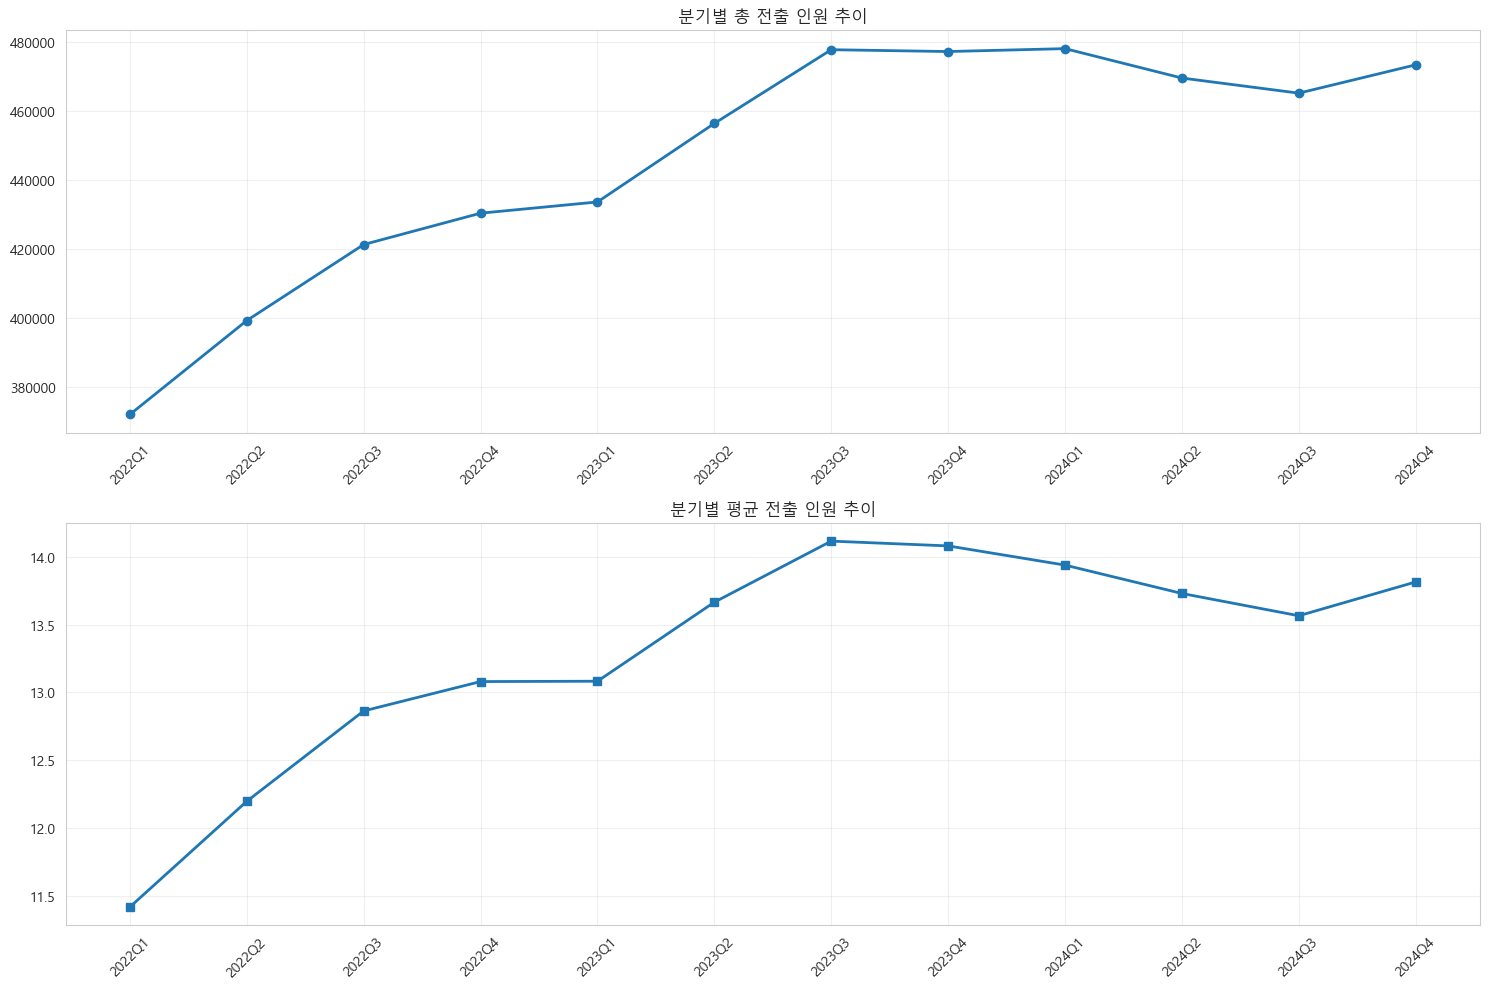

In [6]:
# 분기 컬럼 생성
df['분기'] = df['BS_YR_MON'].dt.to_period('Q')

# 분기별 전출 추이
print("분기별 전출 현황:")
quarterly_emigration = df.groupby('분기')['TOT_CNT'].agg(['sum', 'mean', 'count']).reset_index()
quarterly_emigration.columns = ['분기', '총 전출인원', '평균 전출인원', '데이터건수']
print(quarterly_emigration)

# 문자열로 변환 (그래프용)
quarterly_emigration['분기'] = quarterly_emigration['분기'].astype(str)


import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# 총 전출 인원
axes[0].plot(quarterly_emigration['분기'],
             quarterly_emigration['총 전출인원'],
             marker='o', linewidth=2)
axes[0].set_title('분기별 총 전출 인원 추이')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# 평균 전출 인원
axes[1].plot(quarterly_emigration['분기'],
             quarterly_emigration['평균 전출인원'],
             marker='s', linewidth=2)
axes[1].set_title('분기별 평균 전출 인원 추이')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [85]:
# 동별 인원수 집계
dong_counts = (
    df.groupby('읍면동명')['TOT_CNT']
      .sum()
      .reset_index(name='인원수')
      .sort_values('인원수', ascending=False)
)

print(f"동 개수: {dong_counts['읍면동명'].nunique()}")
print(f"\n동별 인원수 (상위 20개):")
print(dong_counts.head(20).to_string(index=False))

print(f"\n동별 인원수 (하위 10개):")
print(dong_counts.tail(10).to_string(index=False))

print(f"\n기술통계:")
print(dong_counts['인원수'].describe())



동 개수: 585

동별 인원수 (상위 20개):
 읍면동명    인원수
  위례동 324088
  운중동 233364
  도촌동 213543
  초월읍 169741
 서현1동 157510
  금곡동 151249
 광남1동 130770
  성남동 115328
 정자1동 101153
 이매2동  91710
  고등동  88317
 곤지암읍  86360
  판교동  85976
 구미1동  83680
 야탑3동  78478
  구미동  78002
  삼평동  76107
  탄벌동  75900
  모현읍  70380
상대원1동  66731

동별 인원수 (하위 10개):
읍면동명  인원수
광명6동    0
광명4동    0
 고삼면    0
 하성면    0
 팔탄면    0
 광적면    0
 강천면    0
회천1동    0
 가산면    0
 흥천면    0

기술통계:
count       585.000000
mean       9153.278632
std       27084.171101
min           0.000000
25%          33.000000
50%         814.000000
75%        4440.000000
max      324088.000000
Name: 인원수, dtype: float64


## 9. 소득대별 분석

소득대별 인원 통계:
CNT_1      514099
CNT_2     1510887
CNT_3     1090356
CNT_4      676311
CNT_5      705149
CNT_6      235899
CNT_7      162488
CNT_8      112830
CNT_9       72178
CNT_10     234725
dtype: int64

소득대별 구성비(%):
CNT_1      9.67
CNT_2     28.43
CNT_3     20.51
CNT_4     12.72
CNT_5     13.27
CNT_6      4.44
CNT_7      3.06
CNT_8      2.12
CNT_9      1.36
CNT_10     4.42
dtype: float64


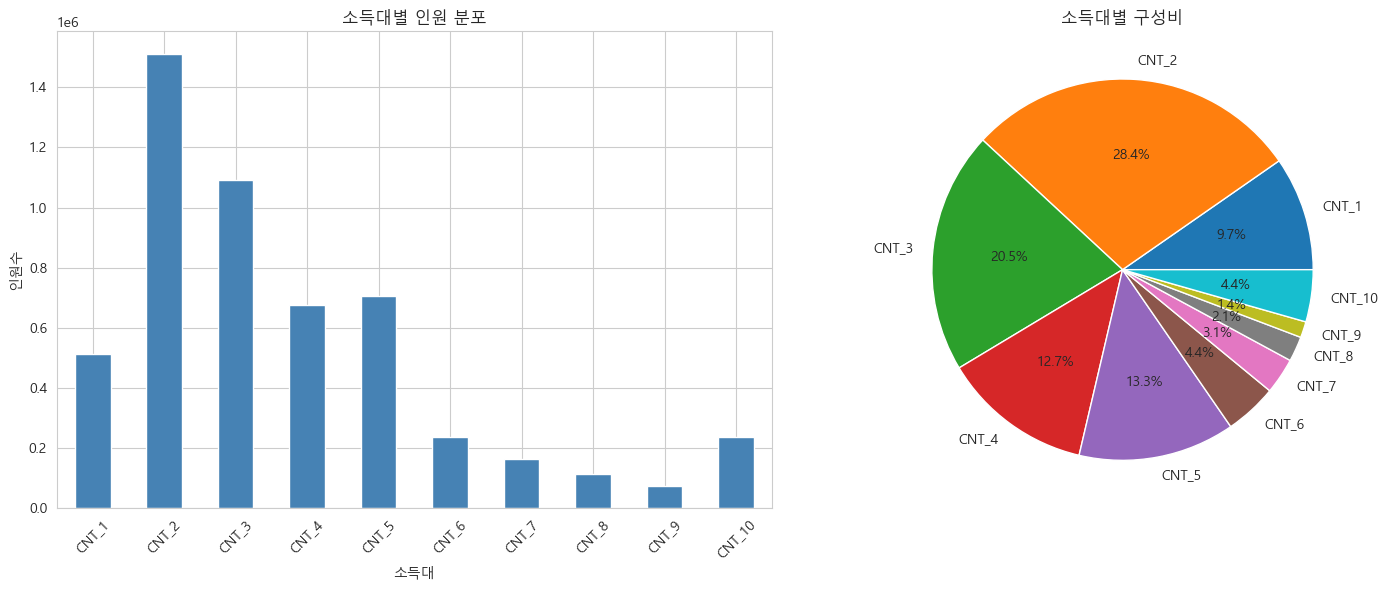

In [11]:
# 소득대별 분포 분석
print("소득대별 인원 통계:")

# CNT_1부터 CNT_10까지의 합계
cnt_cols = [col for col in df.columns if col.startswith('CNT_') and col[-1].isdigit()]
cnt_cols = sorted(cnt_cols, key=lambda x: int(x.split('_')[1]))

income_distribution = df[cnt_cols].sum()
print(income_distribution)

# 소득대별 구성비
print("\n소득대별 구성비(%):")
income_distribution_pct = (income_distribution / income_distribution.sum() * 100)
print(income_distribution_pct.round(2))

# 소득대별 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 막대 그래프
income_distribution.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_xlabel('소득대')
axes[0].set_ylabel('인원수')
axes[0].set_title('소득대별 인원 분포')
axes[0].tick_params(axis='x', rotation=45)

# 원 그래프
axes[1].pie(income_distribution.values, labels=income_distribution.index, autopct='%1.1f%%')
axes[1].set_title('소득대별 구성비')

plt.tight_layout()
plt.show()



## 10. 행정동별 분석

=== 행정동별 전출 현황 ===

행정동별 전출 현황 (상위 20개):
  행정동   총 전출인원  고소득층 전출인원   소득수준_가중평균
  위례동 324088.0   135822.0 4826.041075
  운중동 233364.0   110764.0 5600.195403
  도촌동 213543.0    76380.0 4381.436057
  초월읍 169741.0    45877.0 3513.517653
 서현1동 157510.0    66250.0 4973.627071
  금곡동 151249.0    61635.0 4783.125839
 광남1동 130770.0    35400.0 3675.797201
  성남동 115328.0    27774.0 3449.830050
 정자1동 101153.0    51083.0 5830.533944
 이매2동  91710.0    37700.0 5149.274888
  고등동  88317.0    38073.0 4752.969417
 곤지암읍  86360.0    22950.0 3702.165354
  판교동  85976.0    41346.0 5655.229366
 구미1동  83680.0    32892.0 4634.177820
 야탑3동  78478.0    24076.0 4006.473152
  구미동  78002.0    28884.0 4451.334581
  삼평동  76107.0    34974.0 5480.468288
  탄벌동  75900.0    17289.0 3189.762846
  모현읍  70380.0    21933.0 3809.079284
상대원1동  66731.0    16027.0 3549.474757


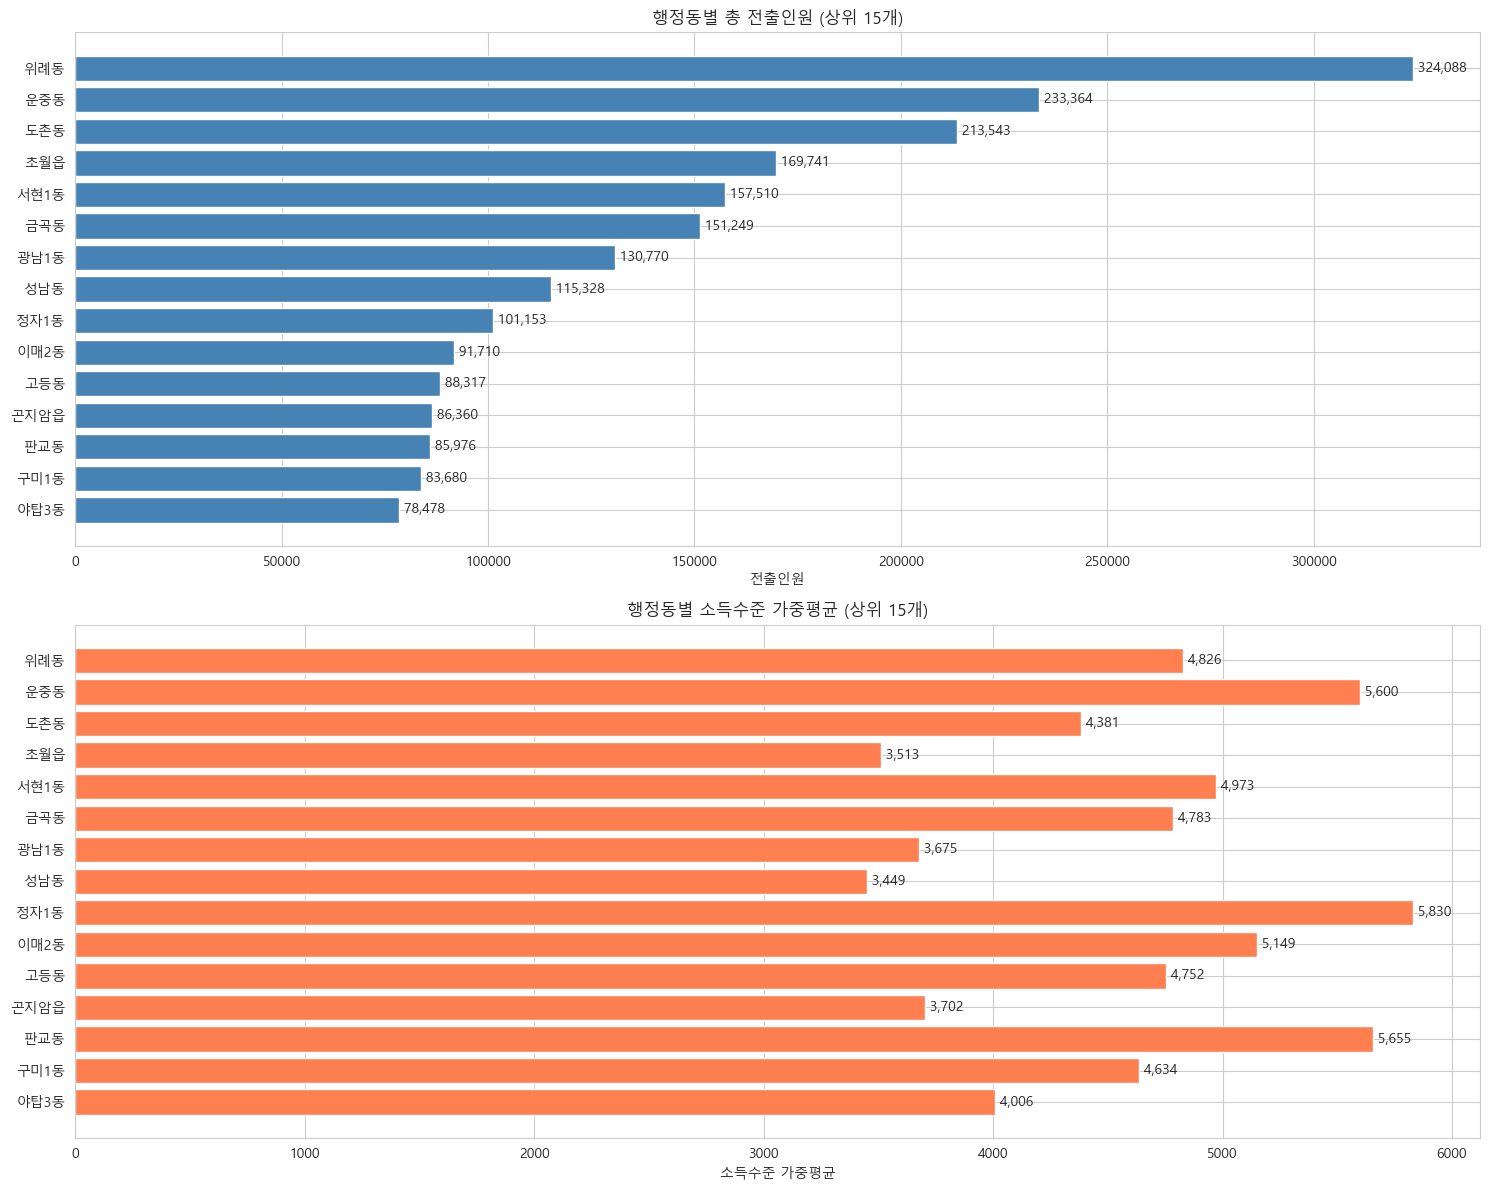

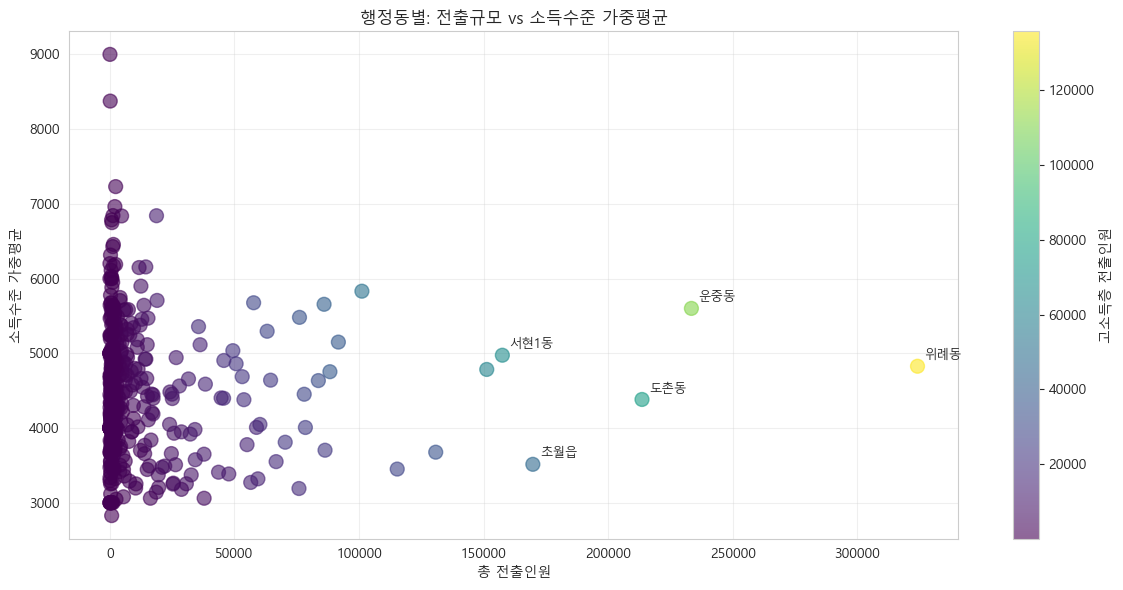

In [15]:
# 행정동별 전출 규모 분석
print("=== 행정동별 전출 현황 ===")

# AVG_INC가 0인 행 제거
df_clean = df[df['AVG_INC'] > 0].copy()

# 행정동별 전출 규모 + 소득수준 가중평균
emigration_by_dong = (
    df_clean.groupby('읍면동명')
    .apply(lambda x: pd.Series({
        '총 전출인원': x['TOT_CNT'].sum(),
        '고소득층 전출인원': x['HIGH_CNT'].sum(),
        '소득수준_가중평균': (x['AVG_INC'] * x['TOT_CNT']).sum() / x['TOT_CNT'].sum()
    }))
    .reset_index()
)

emigration_by_dong = emigration_by_dong.rename(columns={'읍면동명': '행정동'})
emigration_by_dong = emigration_by_dong.sort_values('총 전출인원', ascending=False)

print("\n행정동별 전출 현황 (상위 20개):")
print(emigration_by_dong.head(20).to_string(index=False))


# 시각화 - 상위 15개 행정동
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

top_15 = emigration_by_dong.head(15)

# 전출인원
axes[0].barh(range(len(top_15)), top_15['총 전출인원'].values, color='steelblue')
axes[0].set_yticks(range(len(top_15)))
axes[0].set_yticklabels(top_15['행정동'].values)
axes[0].set_xlabel('전출인원')
axes[0].set_title('행정동별 총 전출인원 (상위 15개)')
axes[0].invert_yaxis()

for i, v in enumerate(top_15['총 전출인원'].values):
    axes[0].text(v, i, f' {int(v):,}', va='center')


# 소득수준 가중평균
axes[1].barh(range(len(top_15)), top_15['소득수준_가중평균'].values, color='coral')
axes[1].set_yticks(range(len(top_15)))
axes[1].set_yticklabels(top_15['행정동'].values)
axes[1].set_xlabel('소득수준 가중평균')
axes[1].set_title('행정동별 소득수준 가중평균 (상위 15개)')
axes[1].invert_yaxis()

for i, v in enumerate(top_15['소득수준_가중평균'].values):
    axes[1].text(v, i, f' {int(v):,.0f}', va='center')

plt.tight_layout()
plt.show()


# 산점도: 전출인원 vs 소득수준 가중평균
plt.figure(figsize=(12, 6))

plt.scatter(
    emigration_by_dong['총 전출인원'],
    emigration_by_dong['소득수준_가중평균'],
    s=100,
    alpha=0.6,
    c=emigration_by_dong['고소득층 전출인원'],
    cmap='viridis'
)

plt.xlabel('총 전출인원')
plt.ylabel('소득수준 가중평균')
plt.title('행정동별: 전출규모 vs 소득수준 가중평균')
plt.colorbar(label='고소득층 전출인원')
plt.grid(True, alpha=0.3)

for idx, row in emigration_by_dong.head(5).iterrows():
    plt.annotate(
        row['행정동'],
        xy=(row['총 전출인원'], row['소득수준_가중평균']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [16]:
df['AVG_INC'].unique()

array([    0,  5000,  4000,  3000,  6000,  9000,  7000,  2000, 19000,
        8000, 10000, 11000, 12000, 15000, 23000, 13000, 14000])

In [26]:
emigration_by_dong

,행정동,총 전출인원,고소득층 전출인원,소득가중합,소득수준,고소득비율
315,위례동,324088,135822,1564062000,4826.041075,0.419090
306,운중동,233364,110764,1306884000,5600.195403,0.474640
87,도촌동,213543,76380,935625000,4381.436057,0.357680
384,초월읍,169741,45877,596388000,3513.517653,0.270276
188,서현1동,157510,66250,783396000,4973.627071,0.420608
...,...,...,...,...,...,...
133,백운동,33,9,132000,4000.000000,0.272727
432,화도읍동부출장소,30,12,120000,4000.000000,0.400000
33,광명5동,30,9,150000,5000.000000,0.300000
330,일산1동,24,6,96000,4000.000000,0.250000


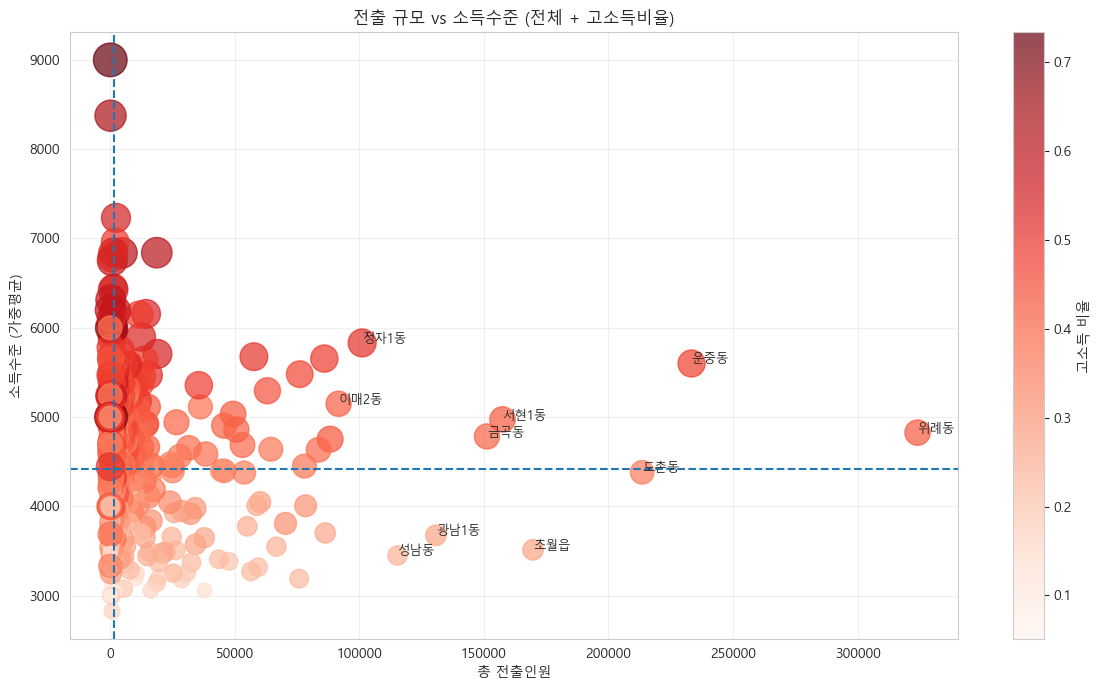

In [16]:
# 1 먼저 실행
df_clean = df[df['AVG_INC'] > 0].copy()

# 2 row 단위 파생변수 생성
df_clean['소득가중합'] = df_clean['AVG_INC'] * df_clean['TOT_CNT']

# 3 행정동별 집계
emigration_by_dong = (
    df_clean.groupby('읍면동명')
    .agg({
        'TOT_CNT': 'sum',
        'HIGH_CNT': 'sum',
        '소득가중합': 'sum'
    })
    .reset_index()
)

# 4 컬럼명 정리
emigration_by_dong = emigration_by_dong.rename(columns={
    '읍면동명': '행정동',
    'TOT_CNT': '총 전출인원',
    'HIGH_CNT': '고소득층 전출인원'
})

# 5 동별 소득수준 가중평균 파생변수 생성
emigration_by_dong['소득수준'] = (
    emigration_by_dong['소득가중합'] /
    emigration_by_dong['총 전출인원']
)

# 6 고소득비율 파생변수 생성
emigration_by_dong['고소득비율'] = (
    emigration_by_dong['고소득층 전출인원'] /
    emigration_by_dong['총 전출인원']
)

# 7 정렬
emigration_by_dong = emigration_by_dong.sort_values('총 전출인원', ascending=False)
#  시각화
plt.figure(figsize=(12, 7))

plt.scatter(
    emigration_by_dong['총 전출인원'],
    emigration_by_dong['소득수준'],
    s=emigration_by_dong['고소득비율'] * 800,
    c=emigration_by_dong['고소득비율'],
    cmap='Reds',
    alpha=0.7
)

plt.axvline(emigration_by_dong['총 전출인원'].median(), linestyle='--')
plt.axhline(emigration_by_dong['소득수준'].median(), linestyle='--')

plt.xlabel('총 전출인원')
plt.ylabel('소득수준 (가중평균)')
plt.title('전출 규모 vs 소득수준 (전체 + 고소득비율)')
plt.colorbar(label='고소득 비율')

plt.grid(True, alpha=0.3)

for _, row in emigration_by_dong.head(10).iterrows():
    plt.annotate(
        row['행정동'],
        (row['총 전출인원'], row['소득수준']),
        fontsize=9
    )

plt.tight_layout()
plt.show()

=== 행정동별 분기별 시계열 분석 ===


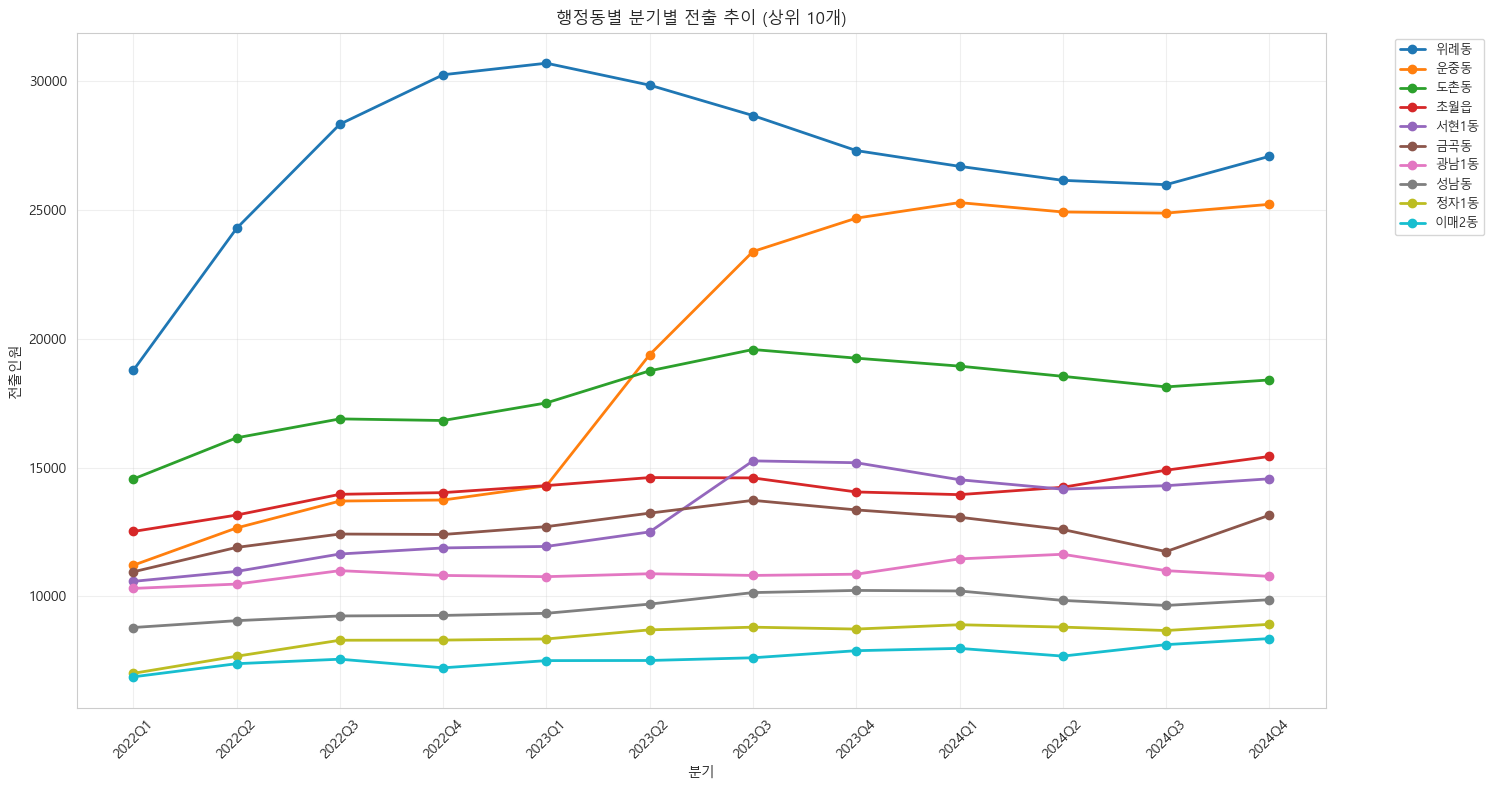


행정동별 분기별 트렌드 분석:
 행정동  초기값(1분기)  최종값(마지막분기)   변화량 변화율(%)    평균
 위례동     18776       27084  8308  44.2% 27007
 운중동     11208       25220 14012 125.0% 19447
 도촌동     14556       18402  3846  26.4% 17795
 초월읍     12519       15431  2912  23.3% 14145
서현1동     10582       14564  3982  37.6% 13125


In [77]:
# 행정동별 분기별 시계열 추이
print("=== 행정동별 분기별 시계열 분석 ===")

# 분기 컬럼이 없으면 생성
if '분기' not in df.columns:
    df['분기'] = df['BS_YR_MON'].dt.to_period('Q')

# 행정동별 분기별 전출 추이
quarterly_by_dong = df.groupby(['분기', '읍면동명'])['TOT_CNT'].sum().reset_index()
quarterly_by_dong['분기_str'] = quarterly_by_dong['분기'].astype(str)

# 상위 10개 행정동 추출
top_10_dongs = emigration_by_dong.head(10)['행정동'].values

# 상위 10개 행정동의 분기별 추이
top_10_quarterly = quarterly_by_dong[quarterly_by_dong['읍면동명'].isin(top_10_dongs)]

# 라인 차트로 시각화
plt.figure(figsize=(15, 8))

for dong in top_10_dongs:
    dong_data = top_10_quarterly[top_10_quarterly['읍면동명'] == dong].sort_values('분기_str')
    plt.plot(range(len(dong_data)), dong_data['TOT_CNT'].values, 
             marker='o', linewidth=2, label=dong, markersize=6)

plt.xlabel('분기')
plt.ylabel('전출인원')
plt.title('행정동별 분기별 전출 추이 (상위 10개)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.xticks(range(len(quarterly_by_dong['분기_str'].unique())), 
           sorted(quarterly_by_dong['분기_str'].unique()), rotation=45)
plt.tight_layout()
plt.show()


# 행정동별 분기 트렌드 통계
print("\n행정동별 분기별 트렌드 분석:")
top_5_dong_trend = []

for dong in top_10_dongs[:5]:
    dong_quarterly = quarterly_by_dong[quarterly_by_dong['읍면동명'] == dong].sort_values('분기_str')
    if len(dong_quarterly) > 1:
        first_val = dong_quarterly['TOT_CNT'].iloc[0]
        last_val = dong_quarterly['TOT_CNT'].iloc[-1]
        change = last_val - first_val
        change_pct = (change / first_val * 100) if first_val > 0 else 0
        avg_val = dong_quarterly['TOT_CNT'].mean()
        
        top_5_dong_trend.append({
            '행정동': dong,
            '초기값(1분기)': int(first_val),
            '최종값(마지막분기)': int(last_val),
            '변화량': int(change),
            '변화율(%)': f'{change_pct:.1f}%',
            '평균': int(avg_val)
        })

trend_df = pd.DataFrame(top_5_dong_trend)
print(trend_df.to_string(index=False))


## 11. 젠트리피케이션 관련 전출 분석

젠트리피케이션 현상 분석: 지역 소득 수준 상승과 저소득층 전출 패턴의 관계


=== 전입 소득층별 분석 ===

사용한 소득분위 컬럼:
['CNT_1', 'CNT_2', 'CNT_3', 'CNT_4', 'CNT_5', 'CNT_6', 'CNT_7', 'CNT_8', 'CNT_9', 'CNT_10']
월별 소득층별 전입 비율(%):
            저소득층_CNT  중산층_CNT  고소득층_CNT
BS_YR_MON                              
2023-01-01      66.9     28.3       4.8
2023-02-01      66.2     28.6       5.3
2023-03-01      66.0     28.7       5.3
2023-04-01      65.9     28.8       5.3
2023-05-01      64.5     29.8       5.7
2023-06-01      64.6     29.7       5.7
2023-07-01      64.2     30.0       5.7
2023-08-01      63.9     30.3       5.8
2023-09-01      63.8     30.4       5.9
2023-10-01      63.6     30.5       5.9
2023-11-01      63.0     31.0       6.0
2023-12-01      62.9     31.1       6.0
2024-01-01      62.7     31.2       6.1
2024-02-01      60.7     32.3       7.0
2024-03-01      60.8     32.3       6.9
2024-04-01      60.6     32.4       7.0
2024-05-01      59.8     33.0       7.2
2024-06-01      59.8     33.1       7.1
2024-07-01      59.7     33.1       7.2
2024-08-01      

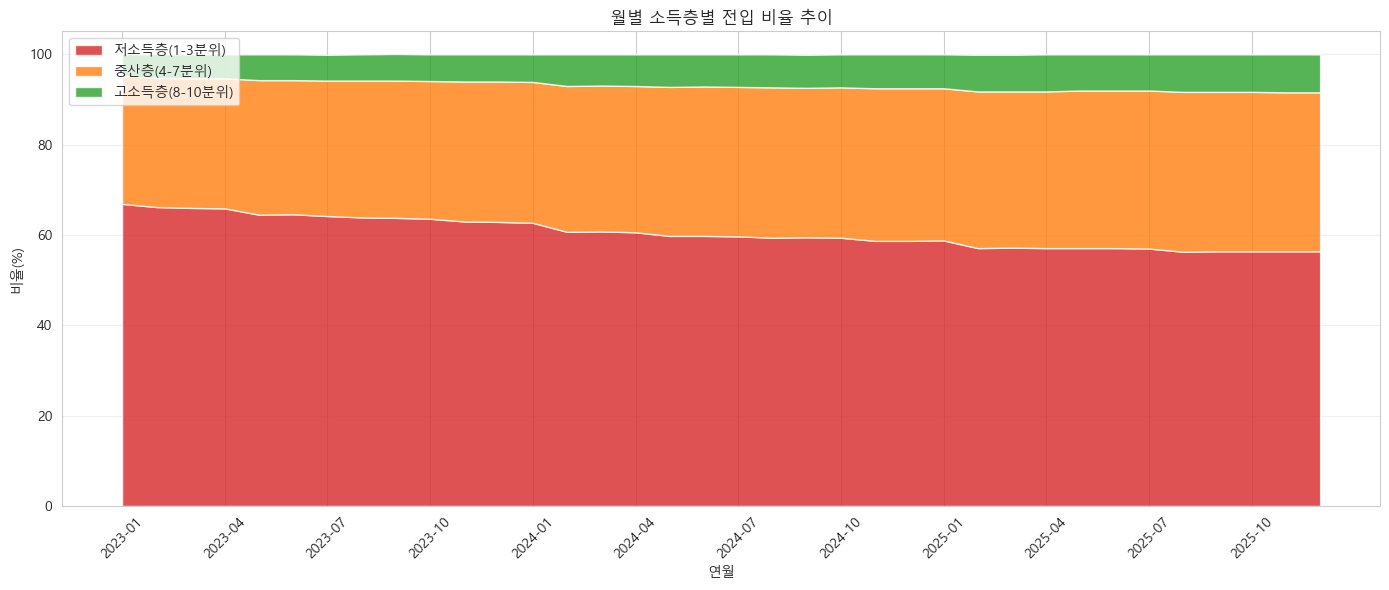

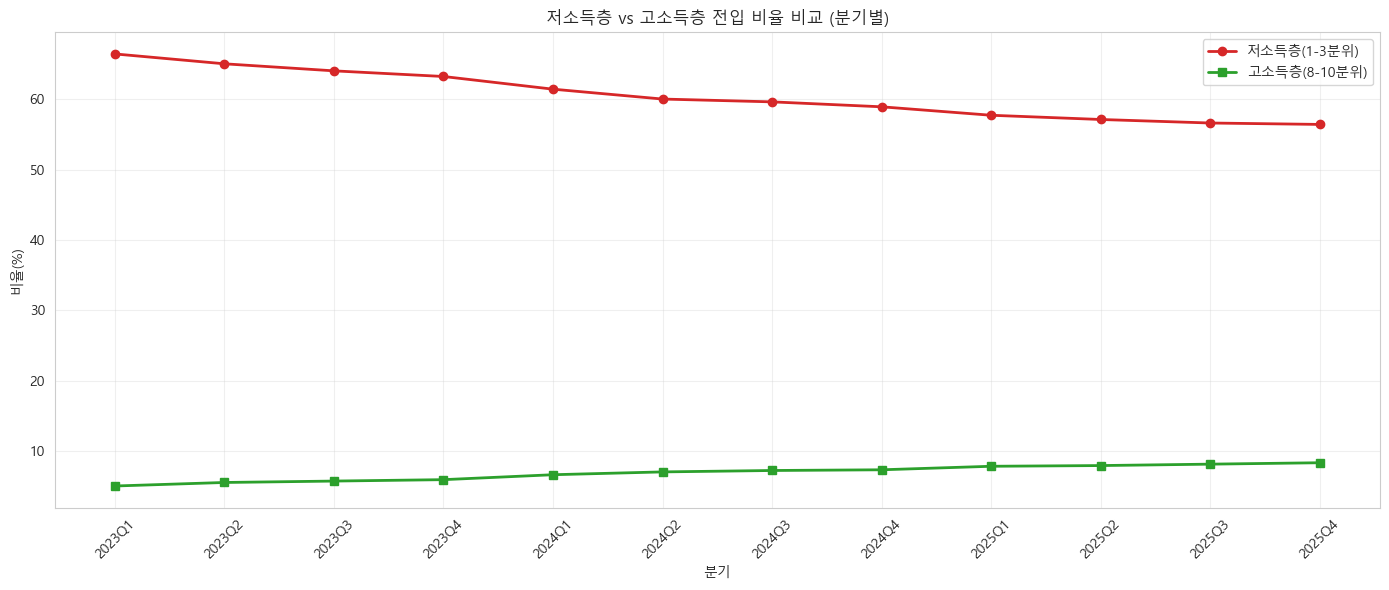

In [78]:
# 전입 데이터 소득층별 분석 및 젠트리피케이션
print("\n=== 전입 소득층별 분석 ===\n")

# BS_YR_MON 날짜형 변환
df_imm['BS_YR_MON'] = pd.to_datetime(df_imm['BS_YR_MON'])

# 소득분위 CNT 컬럼 자동 찾기
cnt_cols_imm = [
    col for col in df_imm.columns
    if col.startswith('CNT_') and col.split('_')[1].isdigit()
]

cnt_cols_imm = sorted(cnt_cols_imm, key=lambda x: int(x.split('_')[1]))

print("사용한 소득분위 컬럼:")
print(cnt_cols_imm)

# 저소득층, 중산층, 고소득층 구분
low_income_cols_imm = [col for col in cnt_cols_imm if int(col.split('_')[1]) <= 3]
middle_income_cols_imm = [col for col in cnt_cols_imm if 4 <= int(col.split('_')[1]) <= 7]
high_income_cols_imm = [col for col in cnt_cols_imm if int(col.split('_')[1]) >= 8]

df_imm['저소득층_CNT'] = df_imm[low_income_cols_imm].sum(axis=1)
df_imm['중산층_CNT'] = df_imm[middle_income_cols_imm].sum(axis=1)
df_imm['고소득층_CNT'] = df_imm[high_income_cols_imm].sum(axis=1)

# 월별 소득층별 비율
monthly_income_ratio_imm = df_imm.groupby('BS_YR_MON')[
    ['저소득층_CNT', '중산층_CNT', '고소득층_CNT']
].sum()

monthly_income_ratio_imm['총계'] = monthly_income_ratio_imm.sum(axis=1)

monthly_income_ratio_pct_imm = monthly_income_ratio_imm.copy()

for col in ['저소득층_CNT', '중산층_CNT', '고소득층_CNT']:
    monthly_income_ratio_pct_imm[col] = (
        monthly_income_ratio_imm[col] / monthly_income_ratio_imm['총계'] * 100
    ).round(1)

print("월별 소득층별 전입 비율(%):")
print(monthly_income_ratio_pct_imm[['저소득층_CNT', '중산층_CNT', '고소득층_CNT']])

# 월별 누적 면적 차트
fig, ax = plt.subplots(figsize=(14, 6))

ax.stackplot(
    range(len(monthly_income_ratio_pct_imm)),
    monthly_income_ratio_pct_imm['저소득층_CNT'],
    monthly_income_ratio_pct_imm['중산층_CNT'],
    monthly_income_ratio_pct_imm['고소득층_CNT'],
    labels=['저소득층(1-3분위)', '중산층(4-7분위)', '고소득층(8-10분위)'],
    colors=['#d62728', '#ff7f0e', '#2ca02c'],
    alpha=0.8
)

ax.set_xlabel('연월')
ax.set_ylabel('비율(%)')
ax.set_title('월별 소득층별 전입 비율 추이')
ax.legend(loc='upper left')

ax.set_xticks(range(0, len(monthly_income_ratio_pct_imm), 3))
ax.set_xticklabels(
    [d.strftime("%Y-%m") for d in monthly_income_ratio_pct_imm.index[::3]],
    rotation=45
)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


# ==============================
# 분기별 소득층별 비율 계산
# ==============================

df_imm['분기'] = df_imm['BS_YR_MON'].dt.to_period('Q')

quarterly_income_ratio_imm = df_imm.groupby('분기')[
    ['저소득층_CNT', '중산층_CNT', '고소득층_CNT']
].sum()

quarterly_income_ratio_imm['총계'] = quarterly_income_ratio_imm.sum(axis=1)

quarterly_income_ratio_pct = quarterly_income_ratio_imm.copy()

for col in ['저소득층_CNT', '중산층_CNT', '고소득층_CNT']:
    quarterly_income_ratio_pct[col] = (
        quarterly_income_ratio_imm[col] / quarterly_income_ratio_imm['총계'] * 100
    ).round(1)

x = range(len(quarterly_income_ratio_pct))

# 라인 차트 비교 (분기)
plt.figure(figsize=(14, 6))

plt.plot(
    x,
    quarterly_income_ratio_pct['저소득층_CNT'],
    marker='o',
    linewidth=2,
    label='저소득층(1-3분위)',
    color='#d62728'
)

plt.plot(
    x,
    quarterly_income_ratio_pct['고소득층_CNT'],
    marker='s',
    linewidth=2,
    label='고소득층(8-10분위)',
    color='#2ca02c'
)

plt.xlabel('분기')
plt.ylabel('비율(%)')
plt.title('저소득층 vs 고소득층 전입 비율 비교 (분기별)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(
    list(x),
    [str(q) for q in quarterly_income_ratio_pct.index],
    rotation=45
)

plt.tight_layout()
plt.show()


=== 행정동별 소득 변화와 저소득층 전출 관계 ===
비교 연도: 2022년 → 2024년

소득 상승 + 저소득층 전출 증가 지역 (상위 15개):
 읍면동명        소득_변화  저소득층_비율_2022  저소득층_비율_2024  저소득층_전출_변화
  운중동  1276.931052          48.4          42.7       18004
상대원2동  -612.501298          84.4          81.5      -11429
  신현동  1507.326007          65.7          58.4        4595
  고등동   863.833200          57.3          49.3        7787
 금광1동  1152.326569          79.3          56.2        4895
  화도읍 -1348.484848          73.7          64.6       -3928
 동탄6동  2916.666667          37.9          41.6        1446
 신흥2동  1255.654009          55.8          49.4        2987
  교하동 -1666.666667          66.8           NaN       -2052
  양지면  1583.333333          64.5          70.4        1826
  매교동  4527.777778           NaN          46.5         578
  대월면 -1638.888889          51.4          48.0       -1518
 신장1동  2109.788360          83.3          66.2        1061
  세교동  2333.333333          49.4          56.7         860
  소흘읍  1166.666667          6

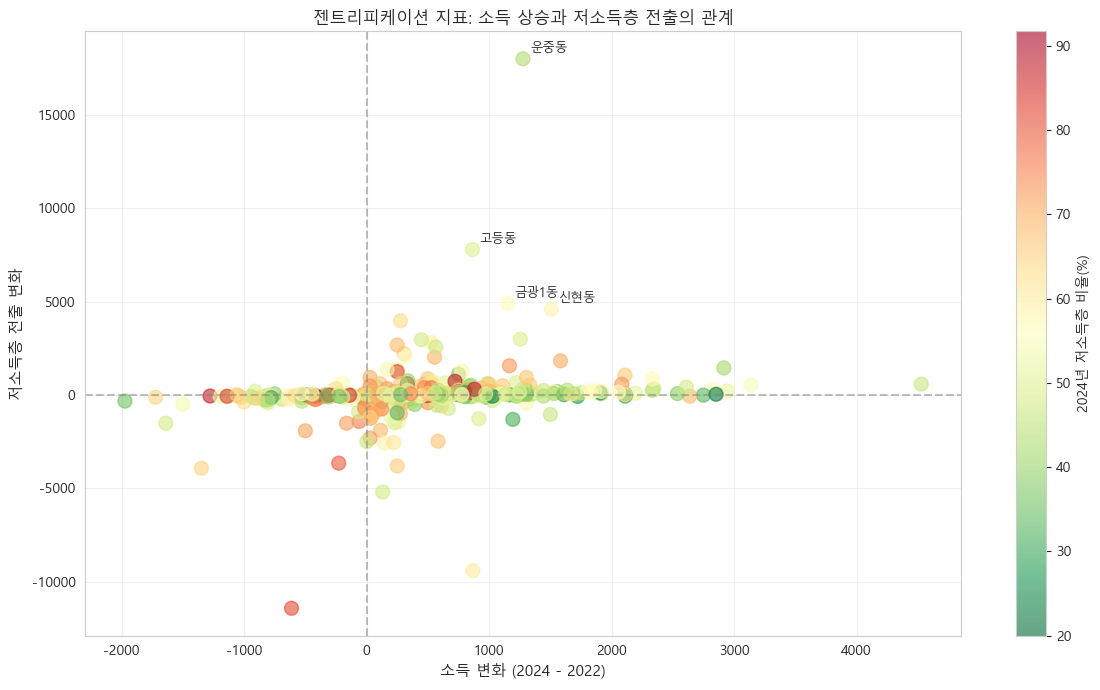



=== 지역별 젠트리피케이션 경향 분류 ===

1. 젠트리피케이션 의심 지역 (소득↑, 저소득층 전출↑):
읍면동명       소득_변화  저소득층_전출_변화  저소득층_비율_2022  저소득층_비율_2024
 운중동 1276.931052       18004          48.4          42.7
 신현동 1507.326007        4595          65.7          58.4
 고등동  863.833200        7787          57.3          49.3
금광1동 1152.326569        4895          79.3          56.2
동탄6동 2916.666667        1446          37.9          41.6
신흥2동 1255.654009        2987          55.8          49.4
 양지면 1583.333333        1826          64.5          70.4
 매교동 4527.777778         578           NaN          46.5
신장1동 2109.788360        1061          83.3          66.2
 세교동 2333.333333         860          49.4          56.7

2. 전출 확대 지역 (소득↑, 전체 전출↑):
읍면동명       소득_변화  TOT_CNT_2022  TOT_CNT_2024
 매교동 4527.777778             0          1242
 서둔동 3138.888889           146          1162
 금정동 2944.444444            11           411
동탄6동 2916.666667          2106          5400
비산2동 2852.941176             0           148
 고덕동 2833.33

In [79]:
# 2. 행정동별 소득 상승 + 저소득층 전출 패턴
print("\n=== 행정동별 소득 변화와 저소득층 전출 관계 ===")

# 날짜형 변환
df['BS_YR_MON'] = pd.to_datetime(df['BS_YR_MON'])

# 소득분위 CNT 컬럼 자동 찾기
cnt_cols = [
    col for col in df.columns
    if col.startswith('CNT_') and col.split('_')[1].isdigit()
]

cnt_cols = sorted(cnt_cols, key=lambda x: int(x.split('_')[1]))

# 저소득층, 중산층, 고소득층 구분
low_cols = [col for col in cnt_cols if int(col.split('_')[1]) <= 3]
middle_cols = [col for col in cnt_cols if 4 <= int(col.split('_')[1]) <= 7]
high_cols = [col for col in cnt_cols if int(col.split('_')[1]) >= 8]

df['저소득층_CNT'] = df[low_cols].sum(axis=1)
df['중산층_CNT'] = df[middle_cols].sum(axis=1)
df['고소득층_CNT'] = df[high_cols].sum(axis=1)

# 연도 생성
df['연도'] = df['BS_YR_MON'].dt.year

# 연도별 행정동 통계
yearly_by_dong = df.groupby(['연도', '읍면동명']).agg({
    'AVG_INC': 'mean',
    '저소득층_CNT': 'sum',
    '고소득층_CNT': 'sum',
    'TOT_CNT': 'sum'
}).reset_index()

# 데이터에 있는 가장 이른 연도 vs 가장 늦은 연도 자동 비교
years = sorted(yearly_by_dong['연도'].unique())
base_yr = years[0]
latest_yr = years[-1]

print(f"비교 연도: {base_yr}년 → {latest_yr}년")

base_year = yearly_by_dong[yearly_by_dong['연도'] == base_yr].copy()
latest_year = yearly_by_dong[yearly_by_dong['연도'] == latest_yr].copy()

comparison = base_year.merge(
    latest_year,
    on='읍면동명',
    suffixes=(f'_{base_yr}', f'_{latest_yr}')
)

# 변화량 계산
comparison['소득_변화'] = comparison[f'AVG_INC_{latest_yr}'] - comparison[f'AVG_INC_{base_yr}']
comparison['저소득층_전출_변화'] = comparison[f'저소득층_CNT_{latest_yr}'] - comparison[f'저소득층_CNT_{base_yr}']

comparison[f'저소득층_비율_{base_yr}'] = (
    comparison[f'저소득층_CNT_{base_yr}'] / comparison[f'TOT_CNT_{base_yr}'] * 100
).round(1)

comparison[f'저소득층_비율_{latest_yr}'] = (
    comparison[f'저소득층_CNT_{latest_yr}'] / comparison[f'TOT_CNT_{latest_yr}'] * 100
).round(1)

# 젠트리피케이션 의심 지표
comparison['젠트리피케이션_지표'] = (
    comparison['소득_변화'] * comparison['저소득층_전출_변화']
)

comparison_sorted = comparison.sort_values('젠트리피케이션_지표', ascending=False)

print("\n소득 상승 + 저소득층 전출 증가 지역 (상위 15개):")
print(
    comparison_sorted[[
        '읍면동명',
        '소득_변화',
        f'저소득층_비율_{base_yr}',
        f'저소득층_비율_{latest_yr}',
        '저소득층_전출_변화'
    ]].head(15).to_string(index=False)
)

# 산점도
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    comparison['소득_변화'],
    comparison['저소득층_전출_변화'],
    s=100,
    alpha=0.6,
    c=comparison[f'저소득층_비율_{latest_yr}'],
    cmap='RdYlGn_r'
)

plt.xlabel(f'소득 변화 ({latest_yr} - {base_yr}) (만원)', fontsize=11)
plt.ylabel('저소득층 전출 변화 (명)', fontsize=11)
plt.title('젠트리피케이션 지표: 소득 상승과 저소득층 전출의 관계', fontsize=12)

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

cbar = plt.colorbar(scatter)
cbar.set_label(f'{latest_yr}년 저소득층 비율(%)', fontsize=10)

plt.grid(True, alpha=0.3)

# 우상향 사분면 라벨
top_gentrification = comparison_sorted.head(5)

for idx, row in top_gentrification.iterrows():
    if row['소득_변화'] > 0 and row['저소득층_전출_변화'] > 0:
        plt.annotate(
            row['읍면동명'][:8],
            xy=(row['소득_변화'], row['저소득층_전출_변화']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9
        )

plt.tight_layout()
plt.show()


# 지역 분류
print("\n\n=== 지역별 젠트리피케이션 경향 분류 ===")

# 소득 증가 + 저소득층 전출 증가
gentrification_mask = (
    (comparison['소득_변화'] > 0) &
    (comparison['저소득층_전출_변화'] > 0)
)

# 소득 증가 + 전체 전출 증가
outflow_growth_mask = (
    (comparison['소득_변화'] > 0) &
    (comparison[f'TOT_CNT_{latest_yr}'] > comparison[f'TOT_CNT_{base_yr}'])
)

# 소득 증가 + 전체 전출 감소
stable_mask = (
    (comparison['소득_변화'] > 0) &
    (comparison[f'TOT_CNT_{latest_yr}'] < comparison[f'TOT_CNT_{base_yr}'])
)

print("\n1. 젠트리피케이션 의심 지역 (소득↑, 저소득층 전출↑):")
gentrification_areas = comparison[gentrification_mask].sort_values(
    '젠트리피케이션_지표',
    ascending=False
)

print(
    gentrification_areas[[
        '읍면동명',
        '소득_변화',
        '저소득층_전출_변화',
        f'저소득층_비율_{base_yr}',
        f'저소득층_비율_{latest_yr}'
    ]].head(10).to_string(index=False)
)

print("\n2. 전출 확대 지역 (소득↑, 전체 전출↑):")
outflow_growth_areas = comparison[outflow_growth_mask].sort_values(
    '소득_변화',
    ascending=False
)

print(
    outflow_growth_areas[[
        '읍면동명',
        '소득_변화',
        f'TOT_CNT_{base_yr}',
        f'TOT_CNT_{latest_yr}'
    ]].head(10).to_string(index=False)
)

print("\n3. 소득 상승 안정 지역 (소득↑, 전체 전출↓):")
stable_areas = comparison[stable_mask].sort_values(
    '소득_변화',
    ascending=False
)

print(
    stable_areas[[
        '읍면동명',
        '소득_변화',
        f'TOT_CNT_{base_yr}',
        f'TOT_CNT_{latest_yr}'
    ]].head(10).to_string(index=False)
)


## 12. 전출 흐름 분석 (어디로 가는가)

=== 전출 흐름 분석: 어디로 가는가? ===

시도별 전출 현황 (경기도 내 이동 제외):
시도명   전출인원        평균소득
 서울 918679 2434.539984
 인천  46004  737.515937

경기도 내 이동(시군구 간): 4,389,985명


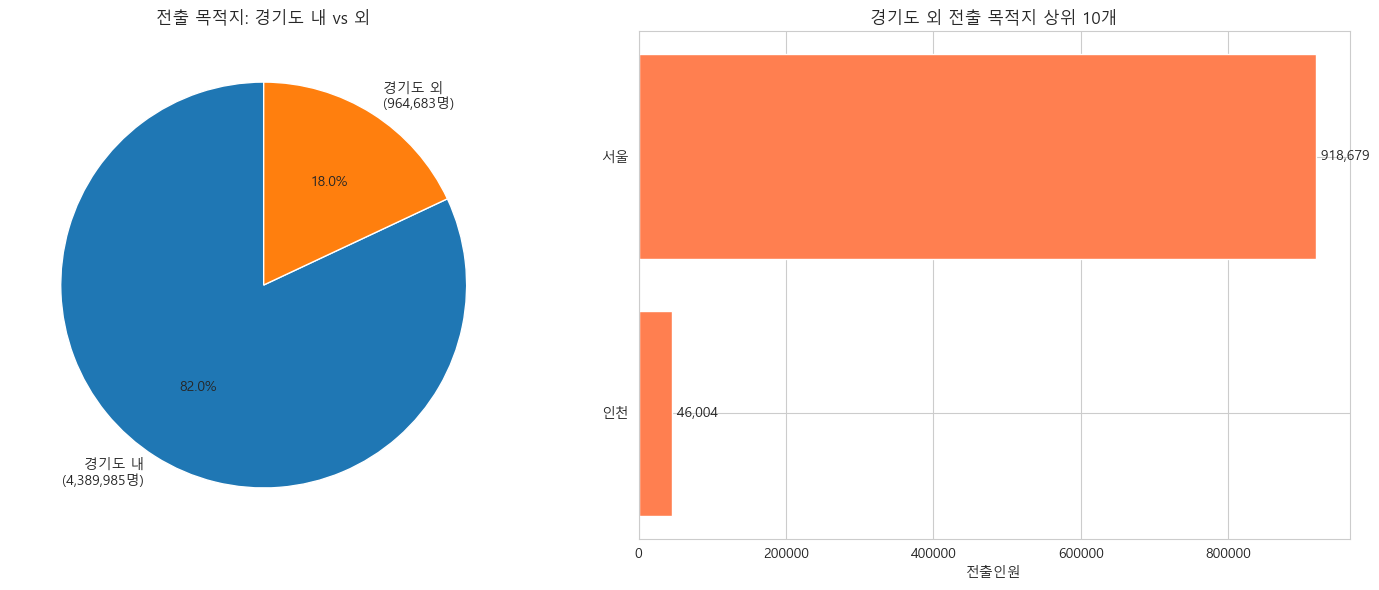

In [80]:
# 1. 전출 시도별 분석
print("=== 전출 흐름 분석: 어디로 가는가? ===")

# 시도별 전출 현황
emigration_by_sido = df.groupby('AF_SIDO').agg({
    'TOT_CNT': 'sum',
    'AVG_INC': 'mean',
    '저소득층_CNT': 'sum',
    '고소득층_CNT': 'sum'
}).reset_index()

emigration_by_sido.columns = ['시도코드', '전출인원', '평균소득', '저소득층', '고소득층']
emigration_by_sido = emigration_by_sido.sort_values('전출인원', ascending=False)

# 시도 코드 해석
sido_dict = {
    11: '서울', 26: '부산', 27: '대구', 28: '인천', 29: '광주',
    30: '대전', 31: '울산', 36: '세종', 41: '경기', 42: '강원',
    43: '충북', 44: '충남', 45: '전북', 46: '전남', 47: '경북',
    48: '경남', 49: '제주'
}

emigration_by_sido['시도명'] = emigration_by_sido['시도코드'].map(sido_dict)

# 시도코드 41은 경기도 (같은 지역 내 이동)
print("\n시도별 전출 현황 (경기도 내 이동 제외):")
emigration_by_sido_other = emigration_by_sido[emigration_by_sido['시도코드'] != 41].copy()
print(emigration_by_sido_other[['시도명', '전출인원', '평균소득']].to_string(index=False))

total_within_gyeonggi = emigration_by_sido[emigration_by_sido['시도코드'] == 41]['전출인원'].sum()
print(f"\n경기도 내 이동(시군구 간): {int(total_within_gyeonggi):,}명")

# 시각화: 전출 목적지 시도
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 경기도 내/외 비교
other_total = emigration_by_sido_other['전출인원'].sum()
data = [total_within_gyeonggi, other_total]
labels = [f'경기도 내\n({int(total_within_gyeonggi):,}명)', f'경기도 외\n({int(other_total):,}명)']
colors = ['#1f77b4', '#ff7f0e']

axes[0].pie(data, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('전출 목적지: 경기도 내 vs 외')

# 경기도 외 상위 시도
top_other_sido = emigration_by_sido_other.head(10)
axes[1].barh(range(len(top_other_sido)), top_other_sido['전출인원'].values, color='coral')
axes[1].set_yticks(range(len(top_other_sido)))
axes[1].set_yticklabels(top_other_sido['시도명'].values)
axes[1].set_xlabel('전출인원')
axes[1].set_title('경기도 외 전출 목적지 상위 10개')
axes[1].invert_yaxis()

for i, v in enumerate(top_other_sido['전출인원'].values):
    axes[1].text(v, i, f' {int(v):,}', va='center')

plt.tight_layout()
plt.show()


In [81]:
# 2. 행정동별 주요 전출처 분석
print("\n=== 행정동별 주요 전출처 분석 ===")

# 행정동별로 어디로 가는지 분석
dong_to_sido = df.groupby(['읍면동명', 'AF_SIDO']).agg({
    'TOT_CNT': 'sum'
}).reset_index()

# 행정동별 주요 전출처 (상위 1개)
main_destination = dong_to_sido.sort_values(['읍면동명', 'TOT_CNT'], ascending=[True, False])
main_destination = main_destination.drop_duplicates('읍면동명', keep='first')

# 시도명 매핑
main_destination['시도명'] = main_destination['AF_SIDO'].map(sido_dict)
main_destination['시도명'] = main_destination['시도명'].fillna('기타')

print("\n상위 20개 행정동의 주요 전출처:")
print(main_destination.sort_values('TOT_CNT', ascending=False)[
    ['읍면동명', '시도명', 'TOT_CNT']
].head(20).to_string(index=False))

# 서울로 가는 행정동들
seoul_emigrants = dong_to_sido[dong_to_sido['AF_SIDO'] == 11].sort_values('TOT_CNT', ascending=False)
print(f"\n\n서울로 가는 행정동 (상위 10개):")
print(seoul_emigrants.head(10)[['읍면동명', 'TOT_CNT']].to_string(index=False))

# 경기도 내 이동 (시군구별)
gyeonggi_internal = df[df['AF_SIDO'] == 41].copy()

# 읍면동별 경기도 내 주요 전출처 시군구
dong_to_signgu = gyeonggi_internal.groupby(['읍면동명', 'AF_SIGNGU']).agg({
    'TOT_CNT': 'sum'
}).reset_index()

main_signgu = dong_to_signgu.sort_values(['읍면동명', 'TOT_CNT'], ascending=[True, False])
main_signgu = main_signgu.drop_duplicates('읍면동명', keep='first')

print(f"\n\n경기도 내 이동 시 주요 목적지 (상위 20개 행정동):")
print(main_signgu.sort_values('TOT_CNT', ascending=False)[
    ['읍면동명', 'AF_SIGNGU', 'TOT_CNT']
].head(20).to_string(index=False))



=== 행정동별 주요 전출처 분석 ===

상위 20개 행정동의 주요 전출처:
 읍면동명 시도명  TOT_CNT
  위례동  경기   209658
  도촌동  경기   172995
  초월읍  경기   169741
  운중동  경기   143032
 광남1동  경기   130770
  금곡동  경기   102211
 서현1동  경기    93464
  성남동  경기    89650
 곤지암읍  경기    86360
  탄벌동  경기    75900
  모현읍  경기    70380
  고등동  경기    68118
 야탑3동  경기    59402
 구미1동  경기    58906
  향남읍  경기    58850
 이매2동  경기    57935
  동천동  경기    57704
상대원1동  경기    56153
 정자1동  경기    55637
  중앙동  경기    55410


서울로 가는 행정동 (상위 10개):
읍면동명  TOT_CNT
 위례동   109554
 운중동    85084
서현1동    60634
 금곡동    46864
정자1동    43008
 도촌동    38478
 판교동    36992
이매2동    33510
 삼평동    26696
구미1동    23742


경기도 내 이동 시 주요 목적지 (상위 20개 행정동):
읍면동명  AF_SIGNGU  TOT_CNT
 도촌동      41135    64647
 초월읍      41133    61776
 위례동      41133    58848
광남1동      41133    53586
 동천동      41135    47848
 탄벌동      41133    40200
 모현읍      41135    37323
곤지암읍      41133    29988
 성남동      41131    29181
 고등동      41135    27079
 금곡동      41465    26332
 운중동      41465    23800
 봉담읍      41135    2

In [14]:
# 3. 소득층별 전출처 비교 (저소득층 vs 고소득층)
print("\n=== 소득층별 전출처 비교 ===")

# 저소득층 전출처
low_income_emigration = df[df['저소득층_CNT'] > 0].copy()
low_income_by_sido = low_income_emigration.groupby('AF_SIDO')['저소득층_CNT'].sum().reset_index()
low_income_by_sido['시도명'] = low_income_by_sido['AF_SIDO'].map(sido_dict).fillna('기타')
low_income_by_sido = low_income_by_sido.sort_values('저소득층_CNT', ascending=False)

# 고소득층 전출처
high_income_emigration = df[df['고소득층_CNT'] > 0].copy()
high_income_by_sido = high_income_emigration.groupby('AF_SIDO')['고소득층_CNT'].sum().reset_index()
high_income_by_sido['시도명'] = high_income_by_sido['AF_SIDO'].map(sido_dict).fillna('기타')
high_income_by_sido = high_income_by_sido.sort_values('고소득층_CNT', ascending=False)

print("\n저소득층 전출 목적지 (상위 10개):")
print(low_income_by_sido.head(10)[['시도명', '저소득층_CNT']].to_string(index=False))

print("\n고소득층 전출 목적지 (상위 10개):")
print(high_income_by_sido.head(10)[['시도명', '고소득층_CNT']].to_string(index=False))

# 시각화: 소득층별 전출처 비교
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 저소득층 상위 10개
low_top = low_income_by_sido.head(10)
axes[0].barh(range(len(low_top)), low_top['저소득층_CNT'].values, color='#d62728')
axes[0].set_yticks(range(len(low_top)))
axes[0].set_yticklabels(low_top['시도명'].values)
axes[0].set_xlabel('전출인원')
axes[0].set_title('저소득층 전출 목적지 상위 10개')
axes[0].invert_yaxis()

# 고소득층 상위 10개
high_top = high_income_by_sido.head(10)
axes[1].barh(range(len(high_top)), high_top['고소득층_CNT'].values, color='#2ca02c')
axes[1].set_yticks(range(len(high_top)))
axes[1].set_yticklabels(high_top['시도명'].values)
axes[1].set_xlabel('전출인원')
axes[1].set_title('고소득층 전출 목적지 상위 10개')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# 저소득층 선호 목적지 vs 고소득층 선호 목적지
print("\n\n=== 소득층별 선호 전출지역 차이 ===")

low_pct = low_income_by_sido.copy()
high_pct = high_income_by_sido.copy()

low_pct['비율(%)'] = (low_pct['저소득층_CNT'] / low_pct['저소득층_CNT'].sum() * 100).round(1)
high_pct['비율(%)'] = (high_pct['고소득층_CNT'] / high_pct['고소득층_CNT'].sum() * 100).round(1)

print("\n저소득층 전출 비율:")
print(low_pct.head(8)[['시도명', '비율(%)']].to_string(index=False))

print("\n고소득층 전출 비율:")
print(high_pct.head(8)[['시도명', '비율(%)']].to_string(index=False))



=== 소득층별 전출처 비교 ===


KeyError: '저소득층_CNT'

In [83]:
# 4. 젠트리피케이션 지역에서의 전출 흐름
print("\n=== 젠트리피케이션 고위험 지역의 전출 흐름 ===")

# 젠트리피케이션 진행 상위 3곳
if 'top_gentrification_dongs' in locals():
    gentrification_emigration = df[df['읍면동명'].isin(top_gentrification_dongs)].copy()
    
    # 지역별 시도 방향 분석
    gentrification_by_sido = gentrification_emigration.groupby(['읍면동명', 'AF_SIDO']).agg({
        'TOT_CNT': 'sum',
        '저소득층_CNT': 'sum'
    }).reset_index()
    
    gentrification_by_sido['시도명'] = gentrification_by_sido['AF_SIDO'].map(sido_dict).fillna('기타')
    
    print(f"\n젠트리피케이션 고위험 지역 ({', '.join(top_gentrification_dongs)})의 전출 흐름:")
    
    for dong in top_gentrification_dongs:
        dong_flow = gentrification_by_sido[gentrification_by_sido['읍면동명'] == dong].sort_values('TOT_CNT', ascending=False)
        print(f"\n  {dong}:")
        for _, row in dong_flow.head(5).iterrows():
            print(f"    - {row['시도명']}: {int(row['TOT_CNT']):,}명 (저소득층: {int(row['저소득층_CNT']):,}명)")
    
    # 시각화
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, dong in enumerate(top_gentrification_dongs):
        dong_flow = gentrification_by_sido[gentrification_by_sido['읍면동명'] == dong].sort_values('TOT_CNT', ascending=False).head(8)
        
        ax = axes[idx]
        ax.barh(range(len(dong_flow)), dong_flow['TOT_CNT'].values, color='steelblue')
        ax.set_yticks(range(len(dong_flow)))
        ax.set_yticklabels(dong_flow['시도명'].values)
        ax.set_xlabel('전출인원')
        ax.set_title(f'{dong}\n전출 목적지')
        ax.invert_yaxis()
        
        for i, v in enumerate(dong_flow['TOT_CNT'].values):
            ax.text(v, i, f' {int(v):,}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# 전출처별 저소득층 비율
print("\n\n=== 전출처별 저소득층 비율 ===")

emigration_by_sido_detail = df.groupby('AF_SIDO').agg({
    'TOT_CNT': 'sum',
    '저소득층_CNT': 'sum'
}).reset_index()

emigration_by_sido_detail['저소득층_비율(%)'] = (
    emigration_by_sido_detail['저소득층_CNT'] / emigration_by_sido_detail['TOT_CNT'] * 100
).round(1)

emigration_by_sido_detail['시도명'] = emigration_by_sido_detail['AF_SIDO'].map(sido_dict).fillna('기타')
emigration_by_sido_detail = emigration_by_sido_detail.sort_values('저소득층_비율(%)', ascending=False)

print("\n저소득층 비율이 높은 전출 목적지:")
print(emigration_by_sido_detail[['시도명', '저소득층_비율(%)']].head(10).to_string(index=False))

print("\n\n=== 분석 요약 ===")
print(f"""
1. 주요 전출 흐름:
   - 경기도 내 이동: {int(total_within_gyeonggi):,}명 ({total_within_gyeonggi/(total_within_gyeonggi + other_total)*100:.1f}%)
   - 경기도 외 이동: {int(other_total):,}명 ({other_total/(total_within_gyeonggi + other_total)*100:.1f}%)
   
2. 경기도 외 주요 목적지: 서울, 인천, 대전 등

3. 소득층별 전출처 차이:
   - 저소득층: 인근 지역(경기도, 인천)으로 이동
   - 고소득층: 서울, 강남권으로 이동 경향

4. 젠트리피케이션 지역의 전출 특징:
   - 저소득층의 강제이주 현상 확인
   - 지역별로 다른 전출 목적지 패턴
""")



=== 젠트리피케이션 고위험 지역의 전출 흐름 ===


=== 전출처별 저소득층 비율 ===

저소득층 비율이 높은 전출 목적지:
시도명  저소득층_비율(%)
 경기        60.5
 인천        57.7
 서울        47.3


=== 분석 요약 ===

1. 주요 전출 흐름:
   - 경기도 내 이동: 4,389,985명 (82.0%)
   - 경기도 외 이동: 964,683명 (18.0%)

2. 경기도 외 주요 목적지: 서울, 인천, 대전 등

3. 소득층별 전출처 차이:
   - 저소득층: 인근 지역(경기도, 인천)으로 이동
   - 고소득층: 서울, 강남권으로 이동 경향

4. 젠트리피케이션 지역의 전출 특징:
   - 저소득층의 강제이주 현상 확인
   - 지역별로 다른 전출 목적지 패턴



## 13. 전입 데이터 탐색적 데이터 분석 (EDA)

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

In [20]:
# 전입 데이터 로드 및 기본 통계
print("=== 전입 데이터 탐색 ===\n")

df_immigration_raw = pd.read_csv('../Data/2차전처리_전입데이터.csv')

print("데이터 형태:", df_immigration_raw.shape)
print("\n첫 5행 확인:")
print(df_immigration_raw.head())

print("\n데이터 정보:")
print(df_immigration_raw.info())

# 데이터 전처리
df_imm = df_immigration_raw.copy()

# 날짜 변환
df_imm['BF_YR_MON'] = pd.to_datetime(df_imm['BF_YR_MON'].astype(str), format='%Y%m')
df_imm['BS_YR_MON'] = pd.to_datetime(df_imm['BS_YR_MON'].astype(str), format='%Y%m')

print("\n\n=== 기본 통계 ===")
print(f"총 전입 인원 합계: {df_imm['TOT_CNT'].sum():,.0f}")
print(f"최대 전입 인원: {df_imm['TOT_CNT'].max():,.0f}")
print(f"평균 전입 인원: {df_imm['TOT_CNT'].mean():,.0f}")
print(f"중앙값 전입 인원: {df_imm['TOT_CNT'].median():,.0f}")

print("\n데이터 통계:")
numeric_cols_imm = df_imm.select_dtypes(include=[np.number]).columns
print(df_imm[numeric_cols_imm].describe().round(2))


=== 전입 데이터 탐색 ===

데이터 형태: (405746, 31)

첫 5행 확인:
   BF_YR_MON  BF_SIDO  BF_SIGNGU  BS_YR_MON  BS_SIGNGU      BS_HCD  TOT_CNT  \
0     202201       41      41131     202301      41111  4111156000        0   
1     202201       41      41131     202301      41111  4111156000        0   
2     202201       41      41133     202301      41111  4111156000       12   
3     202201       41      41133     202301      41111  4111156000       12   
4     202201       41      41135     202301      41111  4111156000        0   

   HIGH_CNT  AVG_INC  AVG_INC_1  ...  CNT_3  CNT_4  CNT_5  CNT_6  CNT_7  \
0         0        0          0  ...      0      0      0      0      0   
1         0        0          0  ...      0      0      0      0      0   
2         1     4000          0  ...      1      5      0      0      0   
3         1     4000          0  ...      1      5      0      0      0   
4         0        0          0  ...      0      0      0      0      0   

   CNT_8  CNT_9  CNT_10 


=== 전입 분포 및 소득 분석 ===



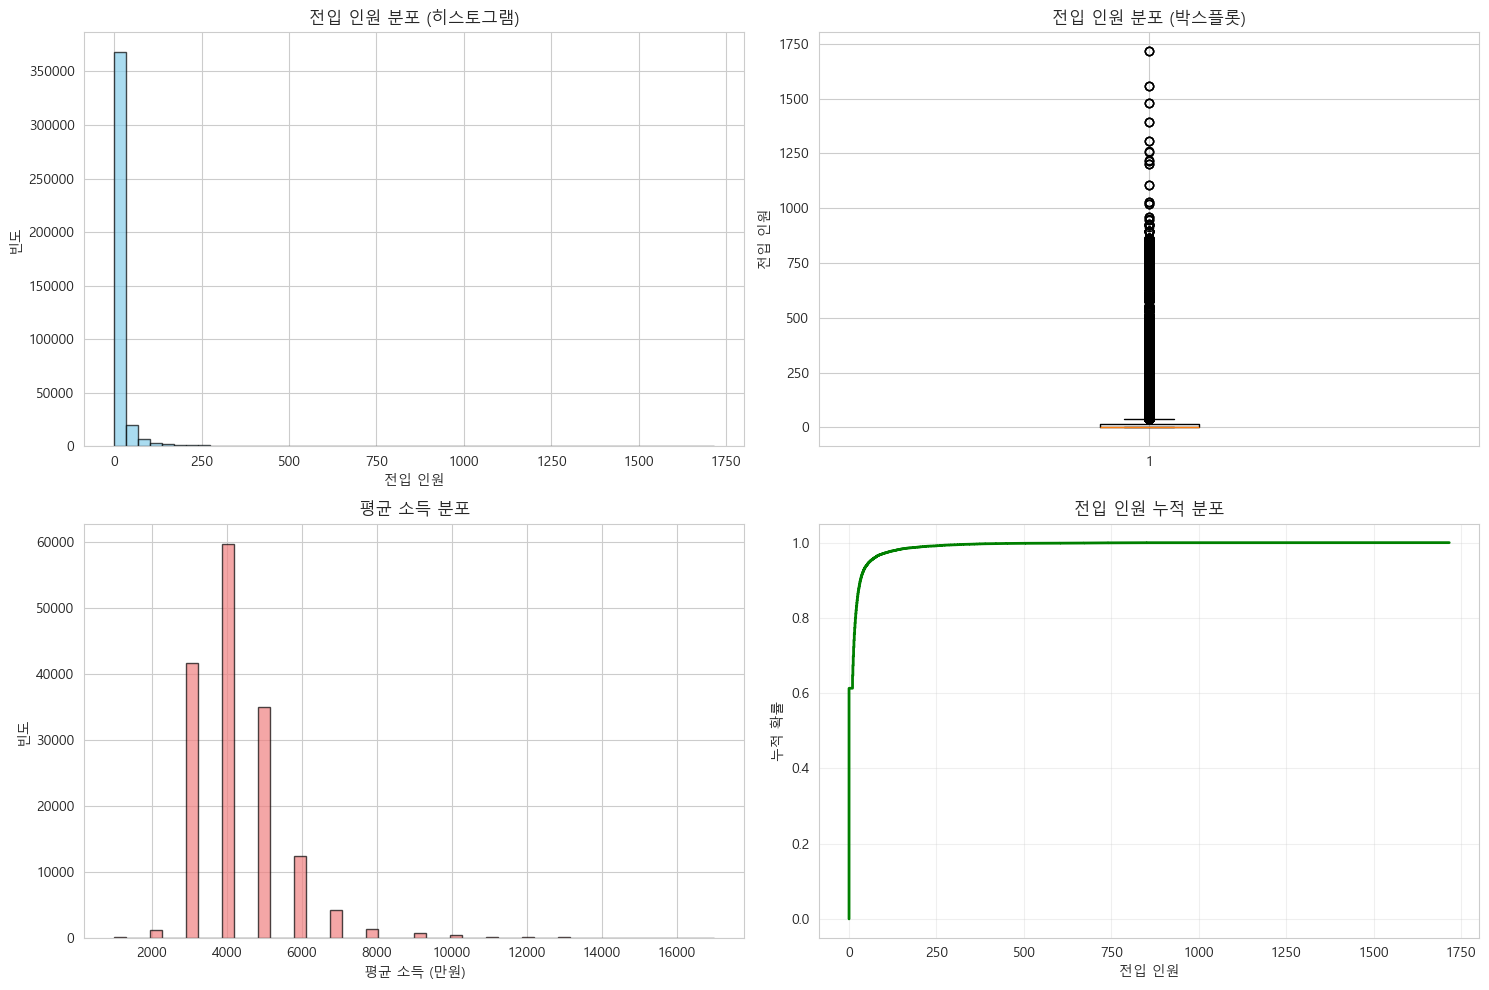

소득대별 전입 인원 통계:
CNT_1      650295
CNT_2     1792650
CNT_3     1250854
CNT_4      776525
CNT_5      785990
CNT_6      259627
CNT_7      177094
CNT_8      115287
CNT_9       76607
CNT_10     237656
dtype: int64

소득대별 구성비(%):
CNT_1     10.62
CNT_2     29.28
CNT_3     20.43
CNT_4     12.68
CNT_5     12.84
CNT_6      4.24
CNT_7      2.89
CNT_8      1.88
CNT_9      1.25
CNT_10     3.88
dtype: float64


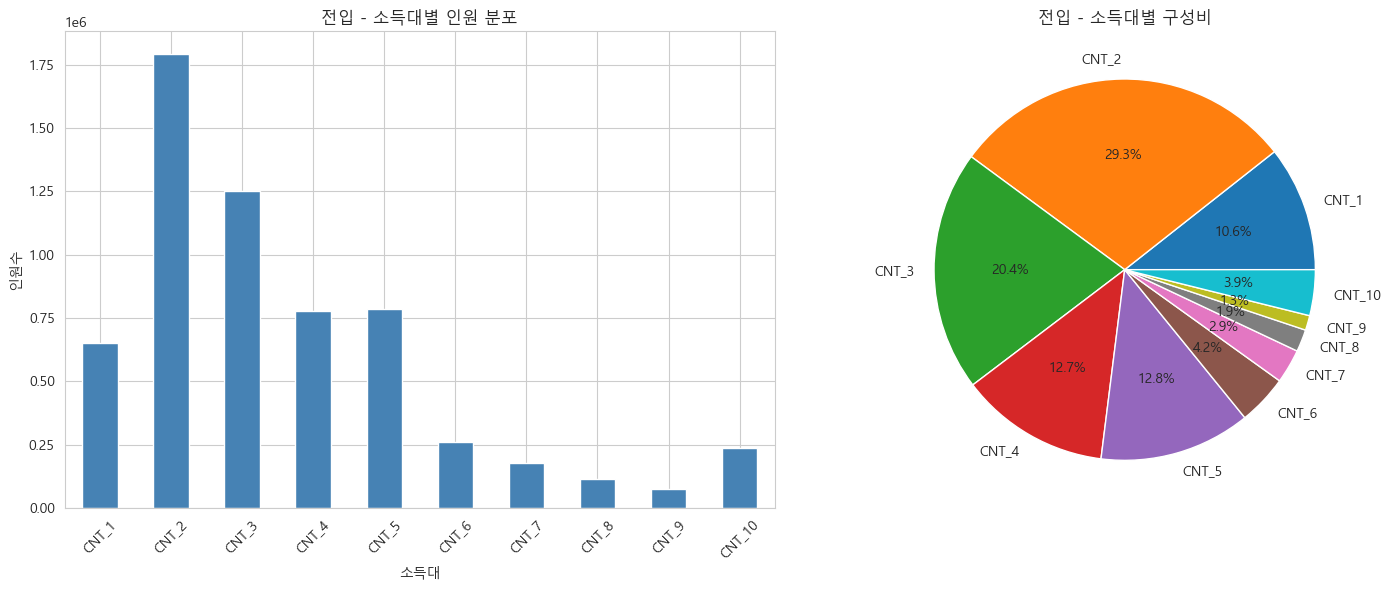

In [21]:
# 전입 분포 시각화 및 소득 분석
print("\n=== 전입 분포 및 소득 분석 ===\n")

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 전입 인원 분포
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 히스토그램
axes[0, 0].hist(df_imm['TOT_CNT'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_xlabel('전입 인원')
axes[0, 0].set_ylabel('빈도')
axes[0, 0].set_title('전입 인원 분포 (히스토그램)')

# 박스플롯
axes[0, 1].boxplot(df_imm['TOT_CNT'])
axes[0, 1].set_ylabel('전입 인원')
axes[0, 1].set_title('전입 인원 분포 (박스플롯)')

# 평균 소득 히스토그램
axes[1, 0].hist(df_imm['AVG_INC'][df_imm['AVG_INC'] > 0], bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1, 0].set_xlabel('평균 소득 (만원)')
axes[1, 0].set_ylabel('빈도')
axes[1, 0].set_title('평균 소득 분포')

# 누적 분포
sorted_tot = np.sort(df_imm['TOT_CNT'])
cumulative = np.arange(1, len(sorted_tot) + 1) / len(sorted_tot)
axes[1, 1].plot(sorted_tot, cumulative, linewidth=2, color='green')
axes[1, 1].set_xlabel('전입 인원')
axes[1, 1].set_ylabel('누적 확률')
axes[1, 1].set_title('전입 인원 누적 분포')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 소득대별 분포
cnt_cols_imm = [col for col in df_imm.columns if col.startswith('CNT_') and col[-1].isdigit()]
cnt_cols_imm = sorted(cnt_cols_imm, key=lambda x: int(x.split('_')[1]))

income_distribution_imm = df_imm[cnt_cols_imm].sum()

print("소득대별 전입 인원 통계:")
print(income_distribution_imm)

print("\n소득대별 구성비(%):")
income_distribution_pct_imm = (income_distribution_imm / income_distribution_imm.sum() * 100)
print(income_distribution_pct_imm.round(2))

# 소득대별 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

income_distribution_imm.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_xlabel('소득대')
axes[0].set_ylabel('인원수')
axes[0].set_title('전입 - 소득대별 인원 분포')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(income_distribution_imm.values, labels=income_distribution_imm.index, autopct='%1.1f%%')
axes[1].set_title('전입 - 소득대별 구성비')

plt.tight_layout()
plt.show()



=== 행정동별 전입 현황 ===

행정동별 전입 현황 (상위 20개):
 행정동   총 전입인원  고소득층 전입인원   소득수준_가중평균
 위례동 364742.0   154678.0 4835.576928
 운중동 331016.0   160828.0 5531.756773
 초월읍 304265.0    77389.0 3310.061953
광남1동 212946.0    49020.0 3213.265335
 도촌동 183894.0    63903.0 4377.239062
서현1동 140880.0    61758.0 5051.078932
 고등동 136998.0    54582.0 4567.716317
 탄벌동 134148.0    25689.0 3075.252706
 금곡동 126715.0    54678.0 5020.092333
신흥2동 122586.0    45745.0 4500.048945
곤지암읍 109888.0    26095.0 3391.089109
 모현읍 107019.0    34596.0 4081.826592
 성남동 103613.0    22269.0 3391.360158
금광1동  97730.0    32035.0 4128.343395
 중앙동  94695.0    29948.0 4086.065790
정자1동  92045.0    45006.0 5760.551904
 봉담읍  91120.0    28577.0 3959.514925
 판교동  89914.0    46462.0 5876.748893
 삼평동  77453.0    37978.0 5529.392018
 향남읍  75636.0    15466.0 3623.036649


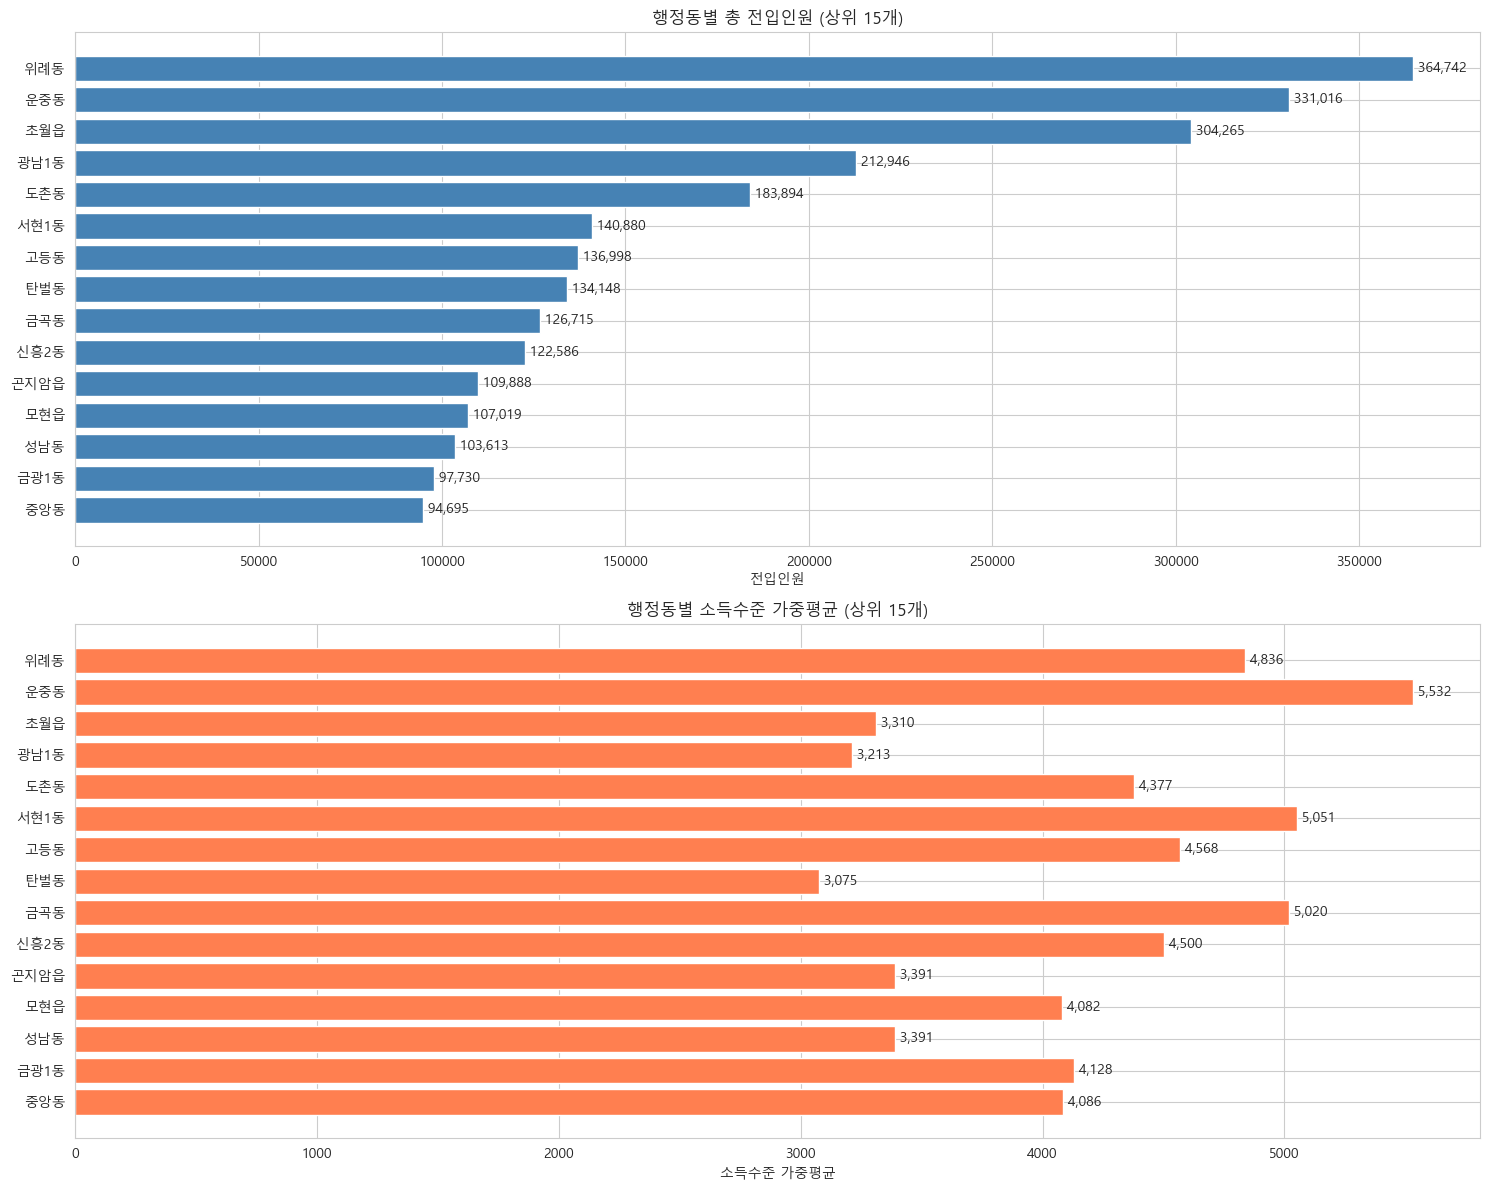

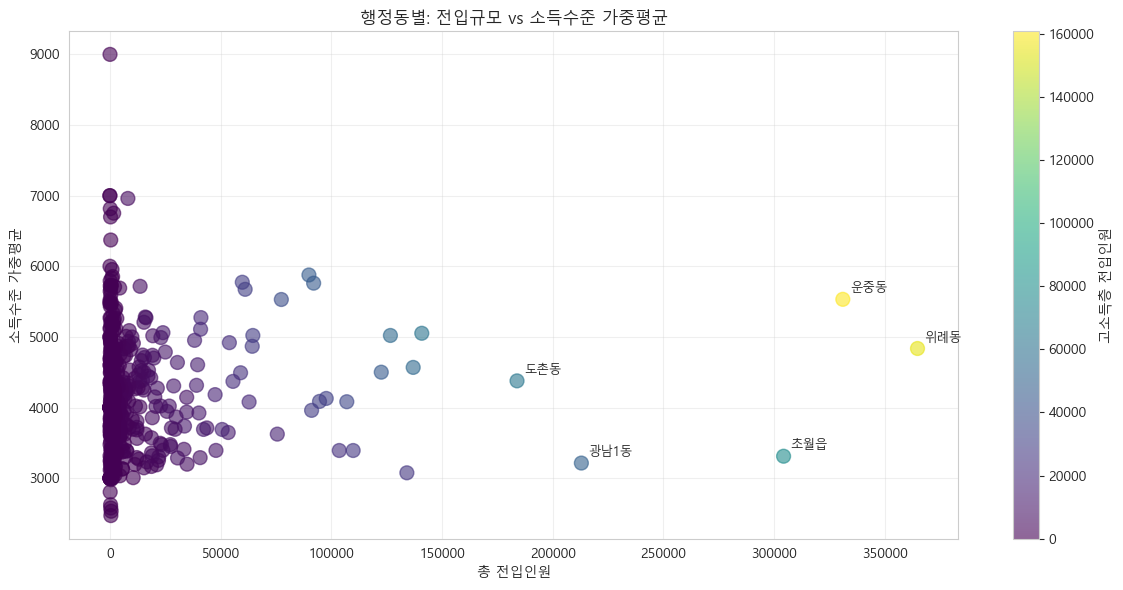



분기별 전입 현황:
        분기  총 전입인원    평균 전입인원  데이터건수
0   2023Q1  432861  13.261267  32641
1   2023Q2  468722  14.183067  33048
2   2023Q3  495262  14.774238  33522
3   2023Q4  501223  15.007126  33399
4   2024Q1  507962  15.033799  33788
5   2024Q2  533385  15.761968  33840
6   2024Q3  549847  16.171971  34000
7   2024Q4  543860  16.076739  33829
8   2025Q1  540558  15.713439  34401
9   2025Q2  528044  15.313613  34482
10  2025Q3  526593  15.301264  34415
11  2025Q4  536201  15.595852  34381


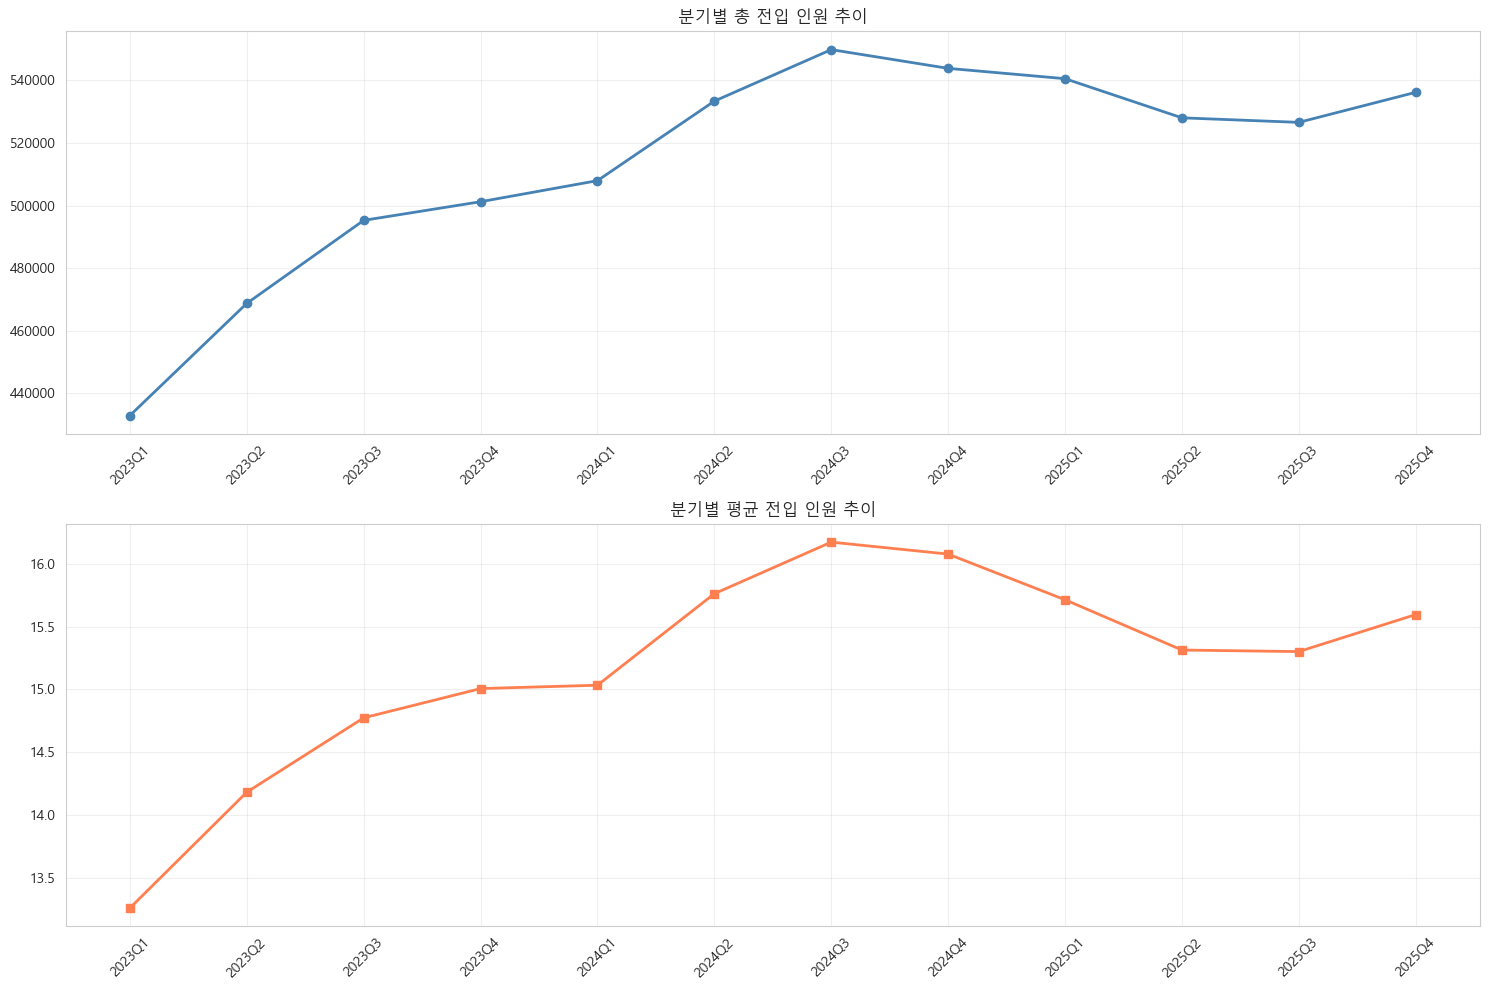

In [22]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 윈도우
plt.rc('font', family='Malgun Gothic')

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


# 행정동별 전입 분석
print("\n=== 행정동별 전입 현황 ===\n")

# AVG_INC가 0인 행 제거
df_imm_clean = df_imm[df_imm['AVG_INC'] > 0].copy()

# 행정동별 전입 규모 + 소득수준 가중평균
immigration_by_dong = (
    df_imm_clean.groupby('읍면동명')
    .apply(lambda x: pd.Series({
        '총 전입인원': x['TOT_CNT'].sum(),
        '고소득층 전입인원': x['HIGH_CNT'].sum(),
        '소득수준_가중평균': (x['AVG_INC'] * x['TOT_CNT']).sum() / x['TOT_CNT'].sum()
    }))
    .reset_index()
)

immigration_by_dong = immigration_by_dong.rename(columns={'읍면동명': '행정동'})
immigration_by_dong = immigration_by_dong.sort_values('총 전입인원', ascending=False)

print("행정동별 전입 현황 (상위 20개):")
print(immigration_by_dong.head(20).to_string(index=False))


# 시각화 - 상위 15개 행정동
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

top_15_imm = immigration_by_dong.head(15)

# 1. 전입인원
axes[0].barh(
    range(len(top_15_imm)),
    top_15_imm['총 전입인원'].values,
    color='steelblue'
)
axes[0].set_yticks(range(len(top_15_imm)))
axes[0].set_yticklabels(top_15_imm['행정동'].values)
axes[0].set_xlabel('전입인원')
axes[0].set_title('행정동별 총 전입인원 (상위 15개)')
axes[0].invert_yaxis()

for i, v in enumerate(top_15_imm['총 전입인원'].values):
    axes[0].text(v, i, f' {int(v):,}', va='center')


# 2. 소득수준 가중평균
axes[1].barh(
    range(len(top_15_imm)),
    top_15_imm['소득수준_가중평균'].values,
    color='coral'
)
axes[1].set_yticks(range(len(top_15_imm)))
axes[1].set_yticklabels(top_15_imm['행정동'].values)
axes[1].set_xlabel('소득수준 가중평균')
axes[1].set_title('행정동별 소득수준 가중평균 (상위 15개)')
axes[1].invert_yaxis()

for i, v in enumerate(top_15_imm['소득수준_가중평균'].values):
    axes[1].text(v, i, f' {v:,.0f}', va='center')

plt.tight_layout()
plt.show()


# 산점도: 전입인원 vs 소득수준 가중평균
plt.figure(figsize=(12, 6))

plt.scatter(
    immigration_by_dong['총 전입인원'],
    immigration_by_dong['소득수준_가중평균'],
    s=100,
    alpha=0.6,
    c=immigration_by_dong['고소득층 전입인원'],
    cmap='viridis'
)

plt.xlabel('총 전입인원')
plt.ylabel('소득수준 가중평균')
plt.title('행정동별: 전입규모 vs 소득수준 가중평균')
plt.colorbar(label='고소득층 전입인원')
plt.grid(True, alpha=0.3)

for idx, row in immigration_by_dong.head(5).iterrows():
    plt.annotate(
        row['행정동'],
        xy=(row['총 전입인원'], row['소득수준_가중평균']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

plt.tight_layout()
plt.show()


# 분기별 분석
df_imm['분기'] = df_imm['BS_YR_MON'].dt.to_period('Q')

quarterly_immigration = (
    df_imm
    .groupby('분기')['TOT_CNT']
    .agg(['sum', 'mean', 'count'])
    .reset_index()
)

quarterly_immigration.columns = ['분기', '총 전입인원', '평균 전입인원', '데이터건수']
quarterly_immigration['분기'] = quarterly_immigration['분기'].astype(str)

print("\n\n분기별 전입 현황:")
print(quarterly_immigration)


# 분기별 추이 시각화
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].plot(
    quarterly_immigration['분기'],
    quarterly_immigration['총 전입인원'],
    marker='o',
    linewidth=2,
    color='steelblue'
)
axes[0].set_title('분기별 총 전입 인원 추이')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    quarterly_immigration['분기'],
    quarterly_immigration['평균 전입인원'],
    marker='s',
    linewidth=2,
    color='coral'
)
axes[1].set_title('분기별 평균 전입 인원 추이')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [25]:
immigration_by_dong

,행정동,총 전입인원,고소득층 전입인원,소득가중합,소득수준_가중평균,고소득비율
327,위례동,364742,154678,1763738000,4835.576928,0.424075
318,운중동,331016,160828,1831100000,5531.756773,0.485862
401,초월읍,304265,77389,1007136000,3310.061953,0.254347
32,광남1동,212946,49020,684252000,3213.265335,0.230199
91,도촌동,183894,63903,804948000,4377.239062,0.347499
...,...,...,...,...,...,...
362,정왕4동,30,6,120000,4000.000000,0.200000
383,중산2동,30,9,120000,4000.000000,0.300000
395,철산2동,28,18,196000,7000.000000,0.642857
379,중4동,12,8,60000,5000.000000,0.666667



행정동별 전입 현황 (상위 20개):
 행정동  총 전입인원  고소득층 전입인원      소득가중합   소득수준_가중평균    고소득비율
 위례동  364742     154678 1763738000 4835.576928 0.424075
 운중동  331016     160828 1831100000 5531.756773 0.485862
 초월읍  304265      77389 1007136000 3310.061953 0.254347
광남1동  212946      49020  684252000 3213.265335 0.230199
 도촌동  183894      63903  804948000 4377.239062 0.347499
서현1동  140880      61758  711596000 5051.078932 0.438373
 고등동  136998      54582  625768000 4567.716317 0.398415
 탄벌동  134148      25689  412539000 3075.252706 0.191497
 금곡동  126715      54678  636121000 5020.092333 0.431504
신흥2동  122586      45745  551643000 4500.048945 0.373167
곤지암읍  109888      26095  372640000 3391.089109 0.237469
 모현읍  107019      34596  436833000 4081.826592 0.323270
 성남동  103613      22269  351389000 3391.360158 0.214925
금광1동   97730      32035  403463000 4128.343395 0.327791
 중앙동   94695      29948  386930000 4086.065790 0.316257
정자1동   92045      45006  530230000 5760.551904 0.488956
 봉담읍   91120      28577  3

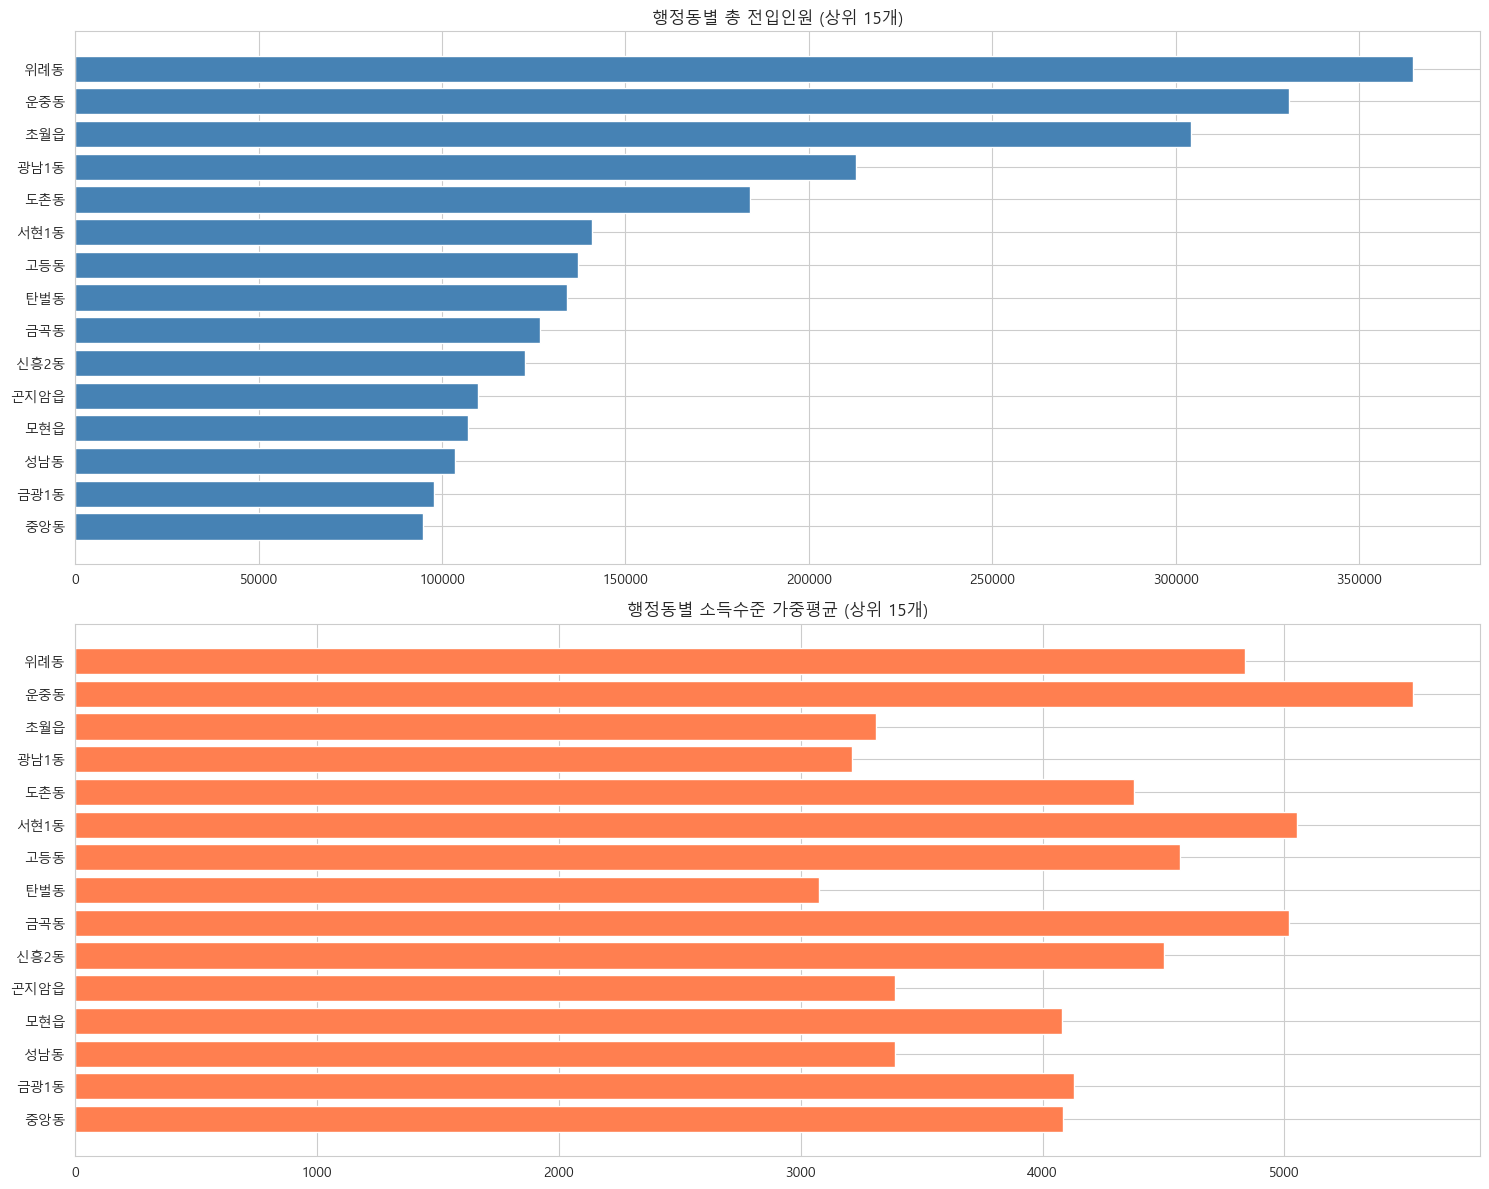

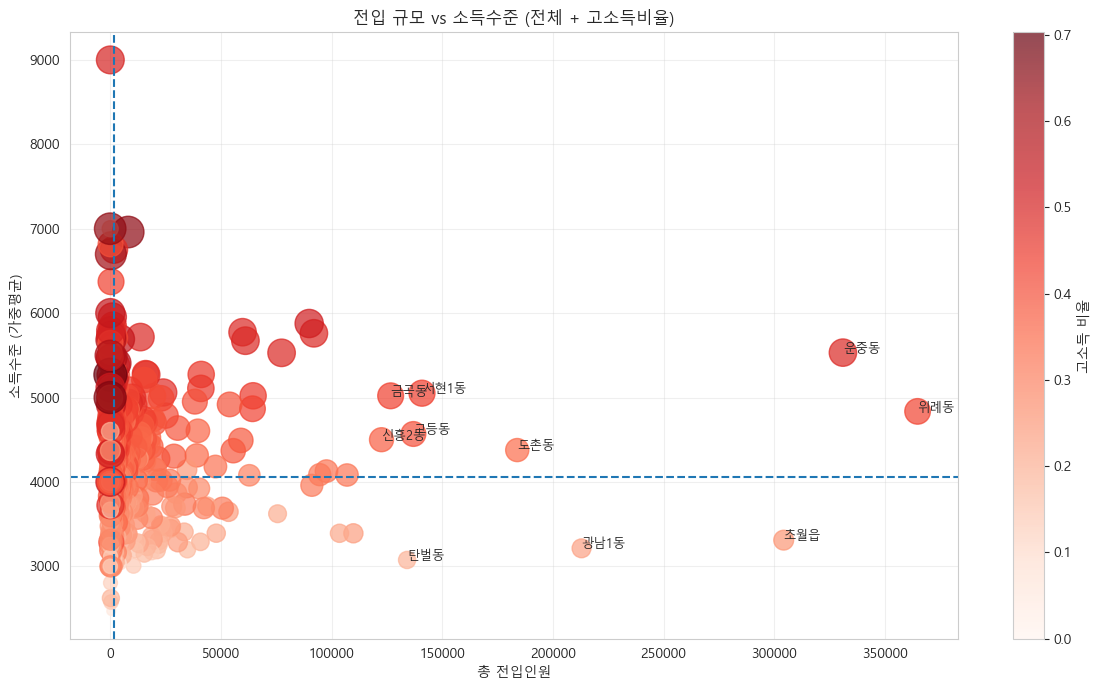

In [23]:
import matplotlib.pyplot as plt

# =====================
# 1️⃣ 전처리
# =====================
df_imm_clean = df_imm[df_imm['AVG_INC'] > 0].copy()

# 🔥 row 기준 파생변수
df_imm_clean['소득가중합'] = df_imm_clean['AVG_INC'] * df_imm_clean['TOT_CNT']


# =====================
# 2️⃣ 행정동별 집계
# =====================
immigration_by_dong = (
    df_imm_clean.groupby('읍면동명')
    .agg({
        'TOT_CNT': 'sum',
        'HIGH_CNT': 'sum',
        '소득가중합': 'sum'
    })
    .reset_index()
)

# 컬럼명 정리
immigration_by_dong = immigration_by_dong.rename(columns={
    '읍면동명': '행정동',
    'TOT_CNT': '총 전입인원',
    'HIGH_CNT': '고소득층 전입인원'
})

# =====================
# 🔥 3️⃣ 파생변수 (핵심)
# =====================
immigration_by_dong['소득수준_가중평균'] = (
    immigration_by_dong['소득가중합'] /
    immigration_by_dong['총 전입인원']
)

immigration_by_dong['고소득비율'] = (
    immigration_by_dong['고소득층 전입인원'] /
    immigration_by_dong['총 전입인원']
)

# 정렬
immigration_by_dong = immigration_by_dong.sort_values('총 전입인원', ascending=False)

print("\n행정동별 전입 현황 (상위 20개):")
print(immigration_by_dong.head(20).to_string(index=False))


# =====================
# 📊 시각화 (전출과 동일 스타일)
# =====================
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

top_15_imm = immigration_by_dong.head(15)

# 전입인원
axes[0].barh(range(len(top_15_imm)), top_15_imm['총 전입인원'].values, color='steelblue')
axes[0].set_yticks(range(len(top_15_imm)))
axes[0].set_yticklabels(top_15_imm['행정동'].values)
axes[0].set_title('행정동별 총 전입인원 (상위 15개)')
axes[0].invert_yaxis()

# 소득수준
axes[1].barh(range(len(top_15_imm)), top_15_imm['소득수준_가중평균'].values, color='coral')
axes[1].set_yticks(range(len(top_15_imm)))
axes[1].set_yticklabels(top_15_imm['행정동'].values)
axes[1].set_title('행정동별 소득수준 가중평균 (상위 15개)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


# =====================
# 📈 산점도 (전출과 동일 구조)
# =====================
plt.figure(figsize=(12, 7))

plt.scatter(
    immigration_by_dong['총 전입인원'],
    immigration_by_dong['소득수준_가중평균'],
    s=immigration_by_dong['고소득비율'] * 800,
    c=immigration_by_dong['고소득비율'],
    cmap='Reds',
    alpha=0.7
)

plt.axvline(immigration_by_dong['총 전입인원'].median(), linestyle='--')
plt.axhline(immigration_by_dong['소득수준_가중평균'].median(), linestyle='--')

plt.xlabel('총 전입인원')
plt.ylabel('소득수준 (가중평균)')
plt.title('전입 규모 vs 소득수준 (전체 + 고소득비율)')
plt.colorbar(label='고소득 비율')
plt.grid(True, alpha=0.3)

for _, row in immigration_by_dong.head(10).iterrows():
    plt.annotate(
        row['행정동'],
        (row['총 전입인원'], row['소득수준_가중평균']),
        fontsize=9
    )

plt.tight_layout()
plt.show()


=== 행정동별 분기별 시계열 분석 ===



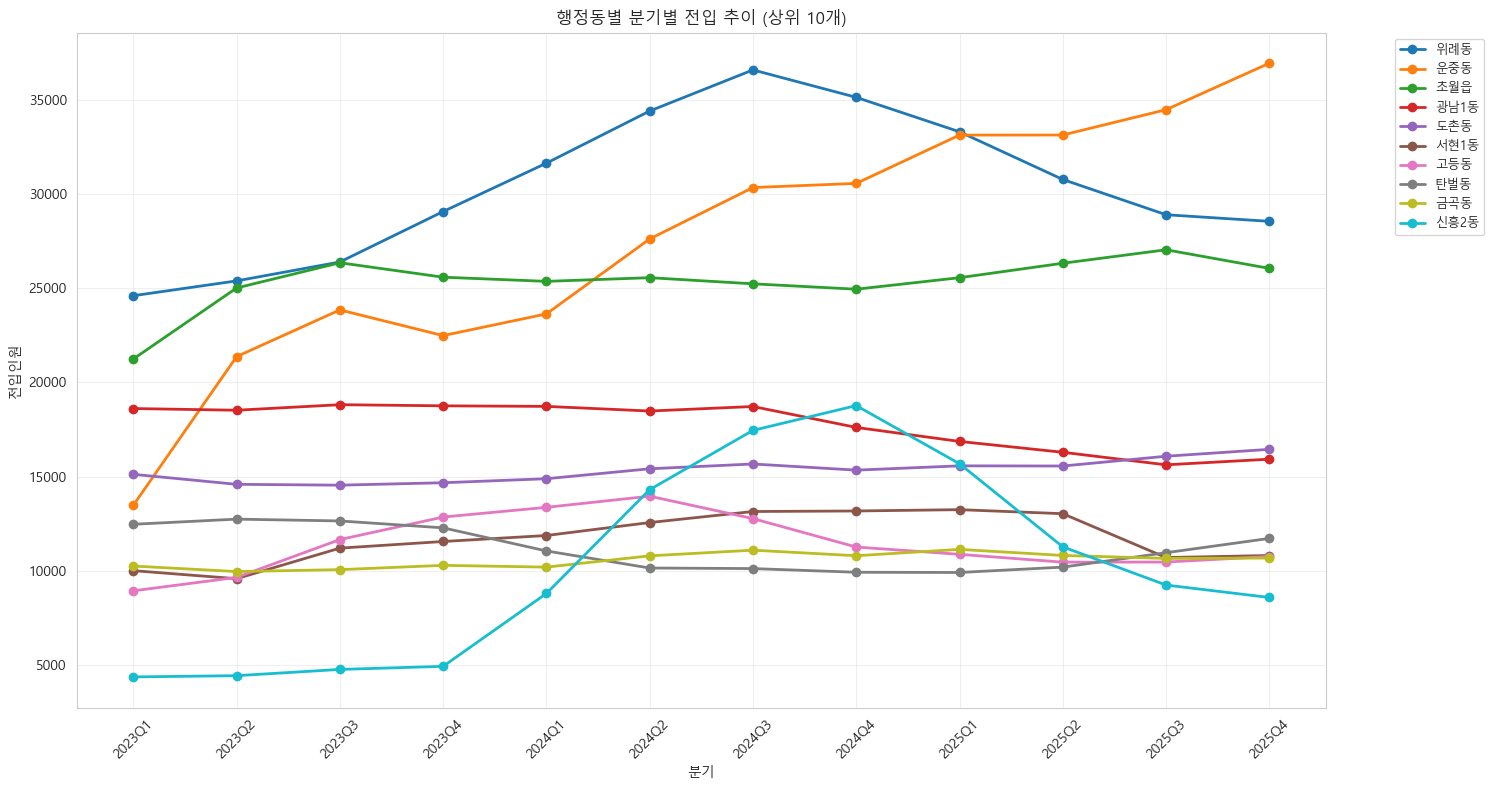

행정동별 분기별 트렌드 분석:
 행정동  초기값(1분기)  최종값(마지막분기)   변화량 변화율(%)    평균
 위례동     24602       28550  3948  16.0% 30395
 운중동     13476       36944 23468 174.1% 27584
 초월읍     21242       26052  4810  22.6% 25355
광남1동     18612       15924 -2688 -14.4% 17745
 도촌동     15120       16446  1326   8.8% 15324


In [ ]:
# 행정동별 분기별 시계열 분석
print("\n=== 행정동별 분기별 시계열 분석 ===\n")

quarterly_by_dong_imm = df_imm.groupby(['분기', '읍면동명'])['TOT_CNT'].sum().reset_index()
quarterly_by_dong_imm['분기_str'] = quarterly_by_dong_imm['분기'].astype(str)

top_10_dongs_imm = immigration_by_dong.head(10)['행정동'].values
top_10_quarterly_imm = quarterly_by_dong_imm[quarterly_by_dong_imm['읍면동명'].isin(top_10_dongs_imm)]

# 라인 차트
plt.figure(figsize=(15, 8))

for dong in top_10_dongs_imm:
    dong_data = top_10_quarterly_imm[top_10_quarterly_imm['읍면동명'] == dong].sort_values('분기_str')
    plt.plot(range(len(dong_data)), dong_data['TOT_CNT'].values, 
             marker='o', linewidth=2, label=dong, markersize=6)

plt.xlabel('분기')
plt.ylabel('전입인원')
plt.title('행정동별 분기별 전입 추이 (상위 10개)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.xticks(range(len(quarterly_by_dong_imm['분기_str'].unique())), 
           sorted(quarterly_by_dong_imm['분기_str'].unique()), rotation=45)
plt.tight_layout()
plt.show()

# 트렌드 분석
print("행정동별 분기별 트렌드 분석:")
top_5_dong_trend_imm = []

for dong in top_10_dongs_imm[:5]:
    dong_quarterly = quarterly_by_dong_imm[quarterly_by_dong_imm['읍면동명'] == dong].sort_values('분기_str')
    if len(dong_quarterly) > 1:
        first_val = dong_quarterly['TOT_CNT'].iloc[0]
        last_val = dong_quarterly['TOT_CNT'].iloc[-1]
        change = last_val - first_val
        change_pct = (change / first_val * 100) if first_val > 0 else 0
        avg_val = dong_quarterly['TOT_CNT'].mean()
        
        top_5_dong_trend_imm.append({
            '행정동': dong,
            '초기값(1분기)': int(first_val),
            '최종값(마지막분기)': int(last_val),
            '변화량': int(change),
            '변화율(%)': f'{change_pct:.1f}%',
            '평균': int(avg_val)
        })

trend_df_imm = pd.DataFrame(top_5_dong_trend_imm)
print(trend_df_imm.to_string(index=False))



=== 전입 소득층별 분석 ===

분기별 소득층별 전입 비율(%):
        저소득층_CNT  중산층_CNT  고소득층_CNT
분기                                 
2023Q1      66.4     28.5       5.1
2023Q2      65.0     29.5       5.6
2023Q3      64.0     30.2       5.8
2023Q4      63.2     30.8       6.0
2024Q1      61.4     32.0       6.7
2024Q2      60.0     32.8       7.1
2024Q3      59.6     33.2       7.3
2024Q4      58.9     33.6       7.4
2025Q1      57.7     34.4       7.9
2025Q2      57.1     34.8       8.0
2025Q3      56.6     35.2       8.2
2025Q4      56.4     35.2       8.4


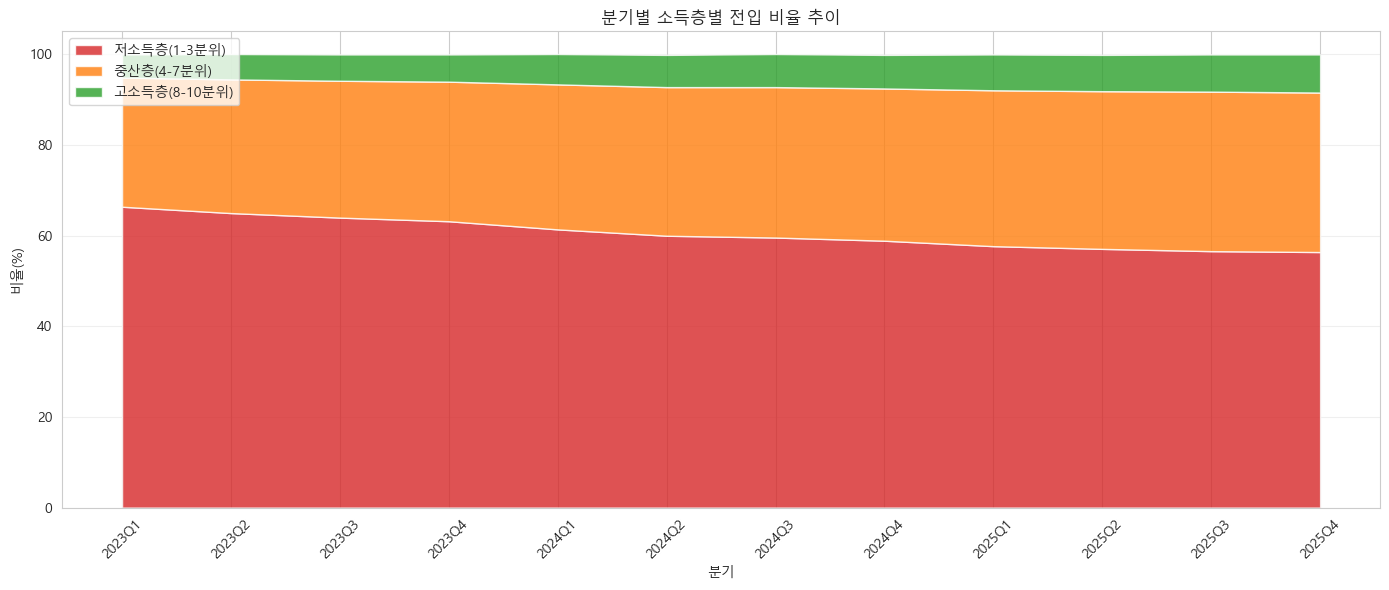

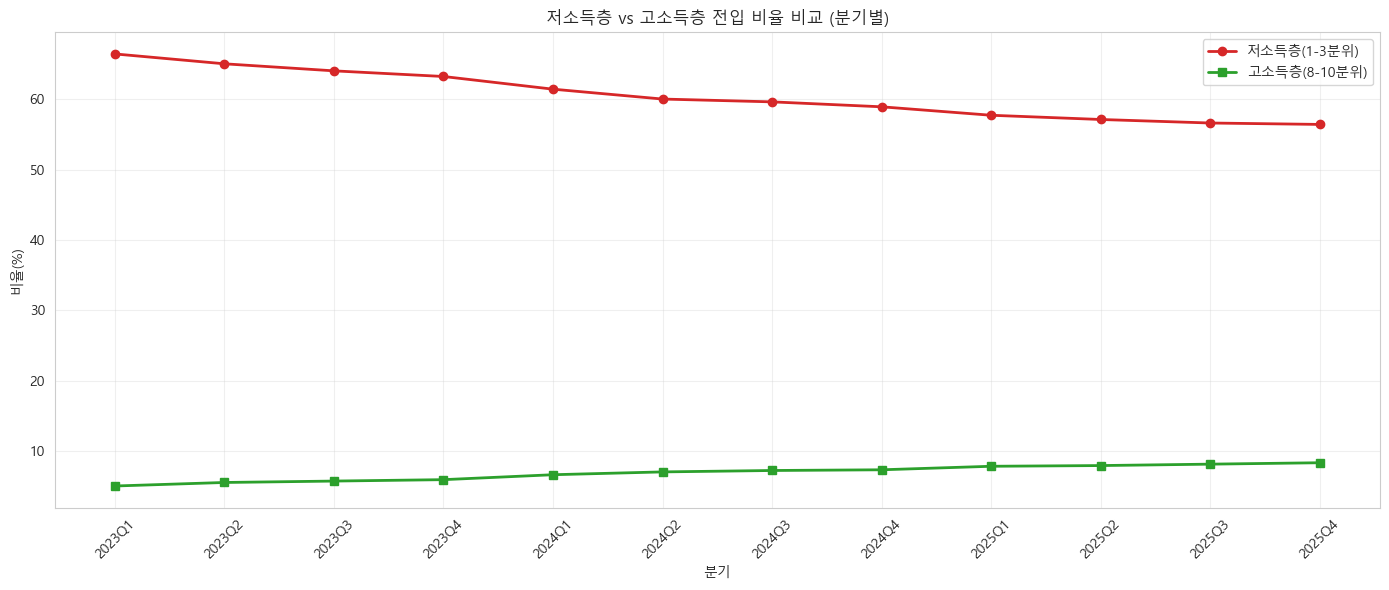


=== 행정동별 소득 변화와 저소득층 전입 관계 ===

비교 연도: 2023 -> 2025
소득이 가장 크게 상승한 행정동 (상위 15개):
읍면동명       소득_변화  저소득층_비율_2023  저소득층_비율_2025  저소득층_전입_변화
비산3동 4472.222222           NaN          43.9         272
 대월면 4250.000000          60.0          61.4        2640
호계1동 3166.666667          58.4          39.9         233
 초평동 3055.555556           NaN          55.9        1530
운정1동 2555.555556          78.6          69.3         468
 화산동 2472.222222          59.2          67.6         780
 창릉동 2416.666667           NaN          42.9         396
다산2동 2333.333333          57.1          58.9         764
호계2동 2250.000000          66.9          49.9         162
 문산읍 2111.111111          66.7          60.0        1848
 비봉면 2055.555556           NaN          67.0        1701
비산2동 2041.666667          50.0          15.2           8
비산1동 1972.222222          52.6          47.9         242
화서2동 1972.222222          63.6          54.0         139
 평안동 1944.444444          54.0          37.0         109


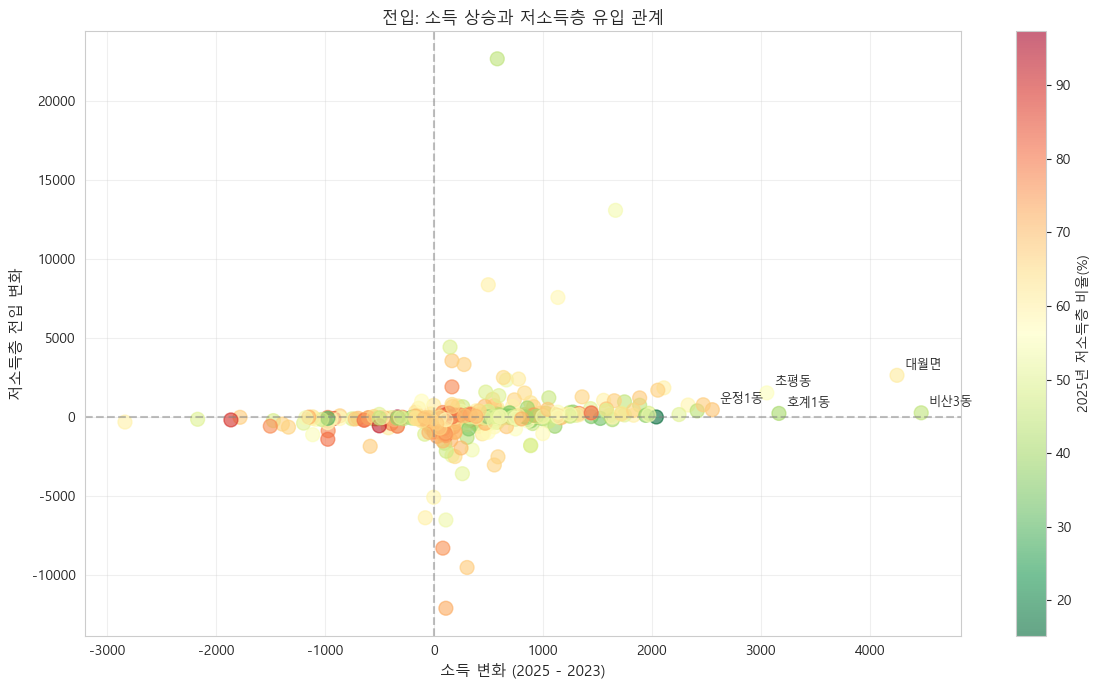

In [24]:
# 전입 데이터 소득층별 분석 및 젠트리피케이션 (분기별)
print("\n=== 전입 소득층별 분석 ===\n")

# 저소득층, 중산층, 고소득층 구분
low_income_cols_imm = [col for col in cnt_cols_imm if int(col.split('_')[1]) <= 3]
middle_income_cols_imm = [col for col in cnt_cols_imm if 4 <= int(col.split('_')[1]) <= 7]
high_income_cols_imm = [col for col in cnt_cols_imm if int(col.split('_')[1]) >= 8]

df_imm['저소득층_CNT'] = df_imm[low_income_cols_imm].sum(axis=1)
df_imm['중산층_CNT'] = df_imm[middle_income_cols_imm].sum(axis=1)
df_imm['고소득층_CNT'] = df_imm[high_income_cols_imm].sum(axis=1)

# 분기 컬럼
df_imm['분기'] = df_imm['BS_YR_MON'].dt.to_period('Q')

# 분기별 소득층별 비율
quarterly_income_ratio_imm = df_imm.groupby('분기')[['저소득층_CNT', '중산층_CNT', '고소득층_CNT']].sum()
quarterly_income_ratio_imm['총계'] = quarterly_income_ratio_imm.sum(axis=1)

quarterly_income_ratio_pct_imm = quarterly_income_ratio_imm.copy()
for col in ['저소득층_CNT', '중산층_CNT', '고소득층_CNT']:
    quarterly_income_ratio_pct_imm[col] = (quarterly_income_ratio_imm[col] / quarterly_income_ratio_imm['총계'] * 100).round(1)

print("분기별 소득층별 전입 비율(%):")
print(quarterly_income_ratio_pct_imm[['저소득층_CNT', '중산층_CNT', '고소득층_CNT']])

# 누적 면적 차트 (분기)
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(quarterly_income_ratio_pct_imm))
ax.stackplot(x,
             quarterly_income_ratio_pct_imm['저소득층_CNT'],
             quarterly_income_ratio_pct_imm['중산층_CNT'],
             quarterly_income_ratio_pct_imm['고소득층_CNT'],
             labels=['저소득층(1-3분위)', '중산층(4-7분위)', '고소득층(8-10분위)'],
             colors=['#d62728', '#ff7f0e', '#2ca02c'], alpha=0.8)

ax.set_xlabel('분기')
ax.set_ylabel('비율(%)')
ax.set_title('분기별 소득층별 전입 비율 추이')
ax.legend(loc='upper left')
ax.set_xticks(list(x))
ax.set_xticklabels([str(q) for q in quarterly_income_ratio_pct_imm.index], rotation=45)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 라인 차트 비교 (분기)
plt.figure(figsize=(14, 6))
plt.plot(x, quarterly_income_ratio_pct_imm['저소득층_CNT'],
         marker='o', linewidth=2, label='저소득층(1-3분위)', color='#d62728')
plt.plot(x, quarterly_income_ratio_pct_imm['고소득층_CNT'],
         marker='s', linewidth=2, label='고소득층(8-10분위)', color='#2ca02c')
plt.xlabel('분기')
plt.ylabel('비율(%)')
plt.title('저소득층 vs 고소득층 전입 비율 비교 (분기별)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(list(x), [str(q) for q in quarterly_income_ratio_pct_imm.index], rotation=45)
plt.tight_layout()
plt.show()

# 행정동별 소득 및 저소득층 전입 변화
print("\n=== 행정동별 소득 변화와 저소득층 전입 관계 ===\n")

df_imm['연도'] = df_imm['BS_YR_MON'].dt.year

yearly_by_dong_imm = df_imm.groupby(['연도', '읍면동명']).agg({
    'AVG_INC': 'mean',
    '저소득층_CNT': 'sum',
    '고소득층_CNT': 'sum',
    'TOT_CNT': 'sum'
}).reset_index()

# 데이터에 존재하는 연도를 자동 감지하여 비교
available_years_imm = sorted(yearly_by_dong_imm['연도'].unique())
base_yr_imm = available_years_imm[0]
latest_yr_imm = available_years_imm[-1]
print(f"비교 연도: {base_yr_imm} -> {latest_yr_imm}")

base_year_imm = yearly_by_dong_imm[yearly_by_dong_imm['연도'] == base_yr_imm].copy()
latest_year_imm = yearly_by_dong_imm[yearly_by_dong_imm['연도'] == latest_yr_imm].copy()

comparison_imm = base_year_imm.merge(
    latest_year_imm, on='읍면동명', suffixes=(f'_{base_yr_imm}', f'_{latest_yr_imm}')
)

comparison_imm['소득_변화'] = comparison_imm[f'AVG_INC_{latest_yr_imm}'] - comparison_imm[f'AVG_INC_{base_yr_imm}']
comparison_imm['저소득층_전입_변화'] = comparison_imm[f'저소득층_CNT_{latest_yr_imm}'] - comparison_imm[f'저소득층_CNT_{base_yr_imm}']
comparison_imm[f'저소득층_비율_{base_yr_imm}'] = (comparison_imm[f'저소득층_CNT_{base_yr_imm}'] / comparison_imm[f'TOT_CNT_{base_yr_imm}'] * 100).round(1)
comparison_imm[f'저소득층_비율_{latest_yr_imm}'] = (comparison_imm[f'저소득층_CNT_{latest_yr_imm}'] / comparison_imm[f'TOT_CNT_{latest_yr_imm}'] * 100).round(1)

comparison_imm_sorted = comparison_imm.sort_values('소득_변화', ascending=False)

print("소득이 가장 크게 상승한 행정동 (상위 15개):")
print(comparison_imm_sorted[[
    '읍면동명', '소득_변화',
    f'저소득층_비율_{base_yr_imm}', f'저소득층_비율_{latest_yr_imm}',
    '저소득층_전입_변화'
]].head(15).to_string(index=False))

# 산점도
plt.figure(figsize=(12, 7))
scatter = plt.scatter(comparison_imm['소득_변화'], comparison_imm['저소득층_전입_변화'],
                     s=100, alpha=0.6, c=comparison_imm[f'저소득층_비율_{latest_yr_imm}'],
                     cmap='RdYlGn_r')
plt.xlabel(f'소득 변화 ({latest_yr_imm} - {base_yr_imm})', fontsize=11)
plt.ylabel('저소득층 전입 변화', fontsize=11)
plt.title('전입: 소득 상승과 저소득층 유입 관계', fontsize=12)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
cbar = plt.colorbar(scatter)
cbar.set_label(f'{latest_yr_imm}년 저소득층 비율(%)', fontsize=10)
plt.grid(True, alpha=0.3)

top_income_increase = comparison_imm_sorted.head(5)
for idx, row in top_income_increase.iterrows():
    if row['소득_변화'] > 0:
        plt.annotate(row['읍면동명'][:8],
                    xy=(row['소득_변화'], row['저소득층_전입_변화']),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()


## 14. 전입 흐름 분석 (어디서 오는가)

=== 전입 흐름 분석: 어디서 오는가? ===

시도별 전입 현황 (경기도 내 이동 제외):
시도명    전입인원        평균소득
 서울 1027919 2600.321001
 인천   32051  602.645417

경기도 내 이동(시군구 간): 5,104,548명


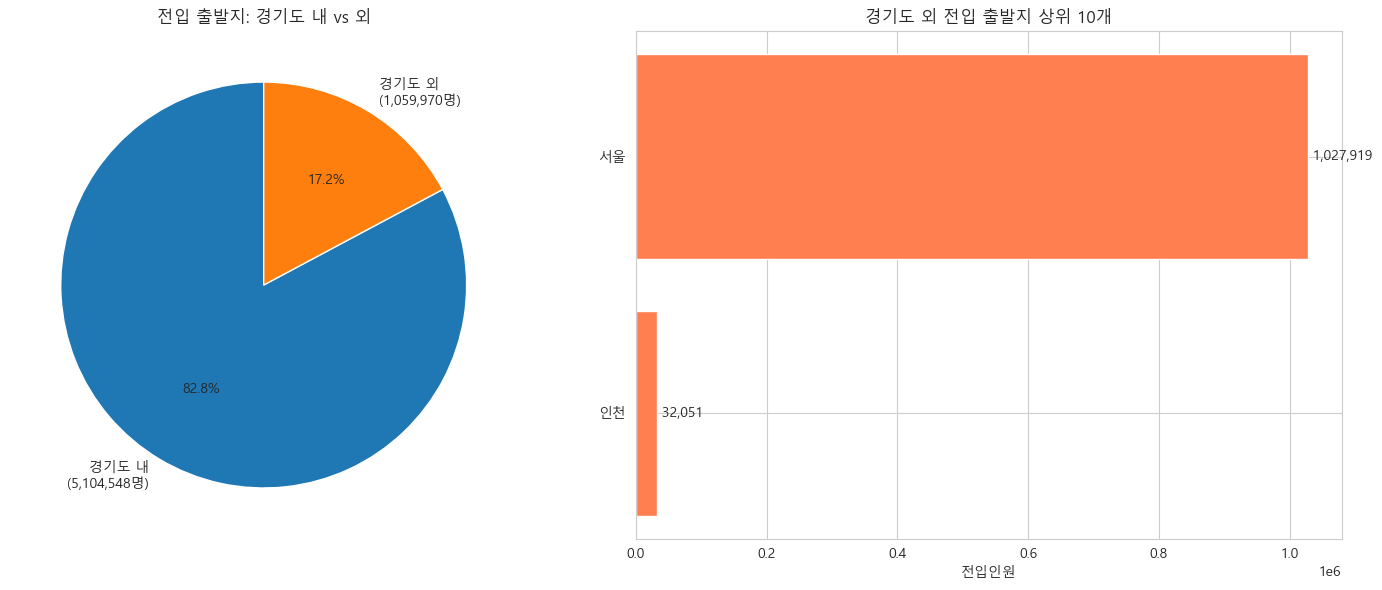

In [ ]:
# 1. 전입 시도별 분석
print("=== 전입 흐름 분석: 어디서 오는가? ===")

# 시도별 전입 현황
immigration_by_sido = df_imm.groupby('BF_SIDO').agg({
    'TOT_CNT': 'sum',
    'AVG_INC': 'mean',
    '저소득층_CNT': 'sum',
    '고소득층_CNT': 'sum'
}).reset_index()

immigration_by_sido.columns = ['시도코드', '전입인원', '평균소득', '저소득층', '고소득층']
immigration_by_sido = immigration_by_sido.sort_values('전입인원', ascending=False)

# 시도 코드 해석
sido_dict = {
    11: '서울', 26: '부산', 27: '대구', 28: '인천', 29: '광주',
    30: '대전', 31: '울산', 36: '세종', 41: '경기', 42: '강원',
    43: '충북', 44: '충남', 45: '전북', 46: '전남', 47: '경북',
    48: '경남', 49: '제주'
}

immigration_by_sido['시도명'] = immigration_by_sido['시도코드'].map(sido_dict)

# 시도코드 41은 경기도 (같은 지역 내 이동)
print("\n시도별 전입 현황 (경기도 내 이동 제외):")
immigration_by_sido_other = immigration_by_sido[immigration_by_sido['시도코드'] != 41].copy()
print(immigration_by_sido_other[['시도명', '전입인원', '평균소득']].to_string(index=False))

total_within_gyeonggi_imm = immigration_by_sido[immigration_by_sido['시도코드'] == 41]['전입인원'].sum()
print(f"\n경기도 내 이동(시군구 간): {int(total_within_gyeonggi_imm):,}명")

# 시각화: 전입 출발지 시도
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 경기도 내/외 비교
other_total_imm = immigration_by_sido_other['전입인원'].sum()
data = [total_within_gyeonggi_imm, other_total_imm]
labels = [f'경기도 내\n({int(total_within_gyeonggi_imm):,}명)', f'경기도 외\n({int(other_total_imm):,}명)']
colors = ['#1f77b4', '#ff7f0e']

axes[0].pie(data, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('전입 출발지: 경기도 내 vs 외')

# 경기도 외 상위 시도
top_other_sido_imm = immigration_by_sido_other.head(10)
axes[1].barh(range(len(top_other_sido_imm)), top_other_sido_imm['전입인원'].values, color='coral')
axes[1].set_yticks(range(len(top_other_sido_imm)))
axes[1].set_yticklabels(top_other_sido_imm['시도명'].values)
axes[1].set_xlabel('전입인원')
axes[1].set_title('경기도 외 전입 출발지 상위 10개')
axes[1].invert_yaxis()

for i, v in enumerate(top_other_sido_imm['전입인원'].values):
    axes[1].text(v, i, f' {int(v):,}', va='center')

plt.tight_layout()
plt.show()


In [ ]:
# 2. 행정동별 주요 전입처 분석
print("\n=== 행정동별 주요 전입처 분석 ===")

# 행정동별로 어디서 오는지 분석
dong_from_sido = df_imm.groupby(['읍면동명', 'BF_SIDO']).agg({
    'TOT_CNT': 'sum'
}).reset_index()

# 행정동별 주요 전입처 (상위 1개)
main_origin = dong_from_sido.sort_values(['읍면동명', 'TOT_CNT'], ascending=[True, False])
main_origin = main_origin.drop_duplicates('읍면동명', keep='first')

# 시도명 매핑
main_origin['시도명'] = main_origin['BF_SIDO'].map(sido_dict)
main_origin['시도명'] = main_origin['시도명'].fillna('기타')

print("\n상위 20개 행정동의 주요 전입처:")
print(main_origin.sort_values('TOT_CNT', ascending=False)[
    ['읍면동명', '시도명', 'TOT_CNT']
].head(20).to_string(index=False))

# 서울에서 오는 행정동들
seoul_immigrants = dong_from_sido[dong_from_sido['BF_SIDO'] == 11].sort_values('TOT_CNT', ascending=False)
print(f"\n\n서울에서 오는 행정동 (상위 10개):")
print(seoul_immigrants.head(10)[['읍면동명', 'TOT_CNT']].to_string(index=False))

# 경기도 내 이동 (시군구별)
gyeonggi_internal_imm = df_imm[df_imm['BF_SIDO'] == 41].copy()

# 읍면동별 경기도 내 주요 전입처 시군구
dong_from_signgu = gyeonggi_internal_imm.groupby(['읍면동명', 'BF_SIGNGU']).agg({
    'TOT_CNT': 'sum'
}).reset_index()

main_signgu_imm = dong_from_signgu.sort_values(['읍면동명', 'TOT_CNT'], ascending=[True, False])
main_signgu_imm = main_signgu_imm.drop_duplicates('읍면동명', keep='first')

print(f"\n\n경기도 내 이동 시 주요 출발지 (상위 20개 행정동):")
print(main_signgu_imm.sort_values('TOT_CNT', ascending=False)[
    ['읍면동명', 'BF_SIGNGU', 'TOT_CNT']
].head(20).to_string(index=False))



=== 행정동별 주요 전입처 분석 ===

상위 20개 행정동의 주요 전입처:
읍면동명 시도명  TOT_CNT
 초월읍  경기   304265
 위례동  경기   223514
광남1동  경기   212946
 운중동  경기   204424
 도촌동  경기   148347
 탄벌동  경기   134148
곤지암읍  경기   109888
 모현읍  경기   107019
 고등동  경기    93549
 봉담읍  경기    91120
서현1동  경기    83442
 중앙동  경기    81550
 금곡동  경기    78331
 성남동  경기    76335
 향남읍  경기    75636
신흥2동  경기    74627
금광1동  경기    67816
 동천동  경기    64586
 남양읍  경기    55616
정자1동  경기    51731


서울에서 오는 행정동 (상위 10개):
읍면동명  TOT_CNT
 위례동   138490
 운중동   122132
서현1동    54036
신흥2동    46710
 금곡동    46236
 고등동    43449
 판교동    38746
정자1동    38242
 도촌동    34746
 삼평동    29917


경기도 내 이동 시 주요 출발지 (상위 20개 행정동):
읍면동명  BF_SIGNGU  TOT_CNT
 초월읍      41133   117663
광남1동      41133    93324
 탄벌동      41133    81336
 도촌동      41135    72096
 위례동      41135    60942
 동천동      41135    56032
 모현읍      41135    51822
 고등동      41135    49239
곤지암읍      41133    44336
 봉담읍      41135    42075
 운중동      41465    38448
 중앙동      41131    31483
금광1동      41131    30681
 성남동      41131


=== 소득층별 전입처 비교 ===

저소득층 전입 출발지 (상위 10개):
시도명  저소득층_CNT
 경기   3181254
 서울    495086
 인천     17459

고소득층 전입 출발지 (상위 10개):
시도명  고소득층_CNT
 경기    316290
 서울    110262
 인천      2998


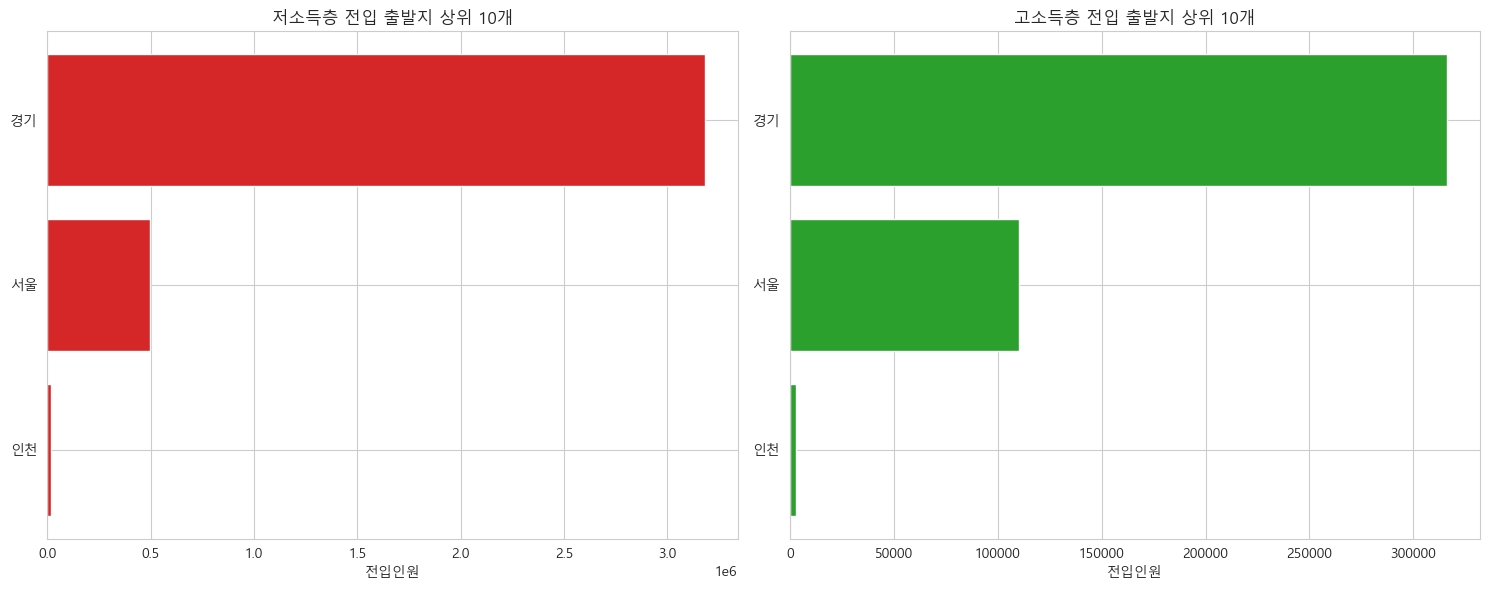



=== 소득층별 선호 전입지역 차이 ===

저소득층 전입 비율:
시도명  비율(%)
 경기   86.1
 서울   13.4
 인천    0.5

고소득층 전입 비율:
시도명  비율(%)
 경기   73.6
 서울   25.7
 인천    0.7


In [ ]:
# 3. 소득층별 전입처 비교 (저소득층 vs 고소득층)
print("\n=== 소득층별 전입처 비교 ===")

# 저소득층 전입처
low_income_immigration = df_imm[df_imm['저소득층_CNT'] > 0].copy()
low_income_by_sido_imm = low_income_immigration.groupby('BF_SIDO')['저소득층_CNT'].sum().reset_index()
low_income_by_sido_imm['시도명'] = low_income_by_sido_imm['BF_SIDO'].map(sido_dict).fillna('기타')
low_income_by_sido_imm = low_income_by_sido_imm.sort_values('저소득층_CNT', ascending=False)

# 고소득층 전입처
high_income_immigration = df_imm[df_imm['고소득층_CNT'] > 0].copy()
high_income_by_sido_imm = high_income_immigration.groupby('BF_SIDO')['고소득층_CNT'].sum().reset_index()
high_income_by_sido_imm['시도명'] = high_income_by_sido_imm['BF_SIDO'].map(sido_dict).fillna('기타')
high_income_by_sido_imm = high_income_by_sido_imm.sort_values('고소득층_CNT', ascending=False)

print("\n저소득층 전입 출발지 (상위 10개):")
print(low_income_by_sido_imm.head(10)[['시도명', '저소득층_CNT']].to_string(index=False))

print("\n고소득층 전입 출발지 (상위 10개):")
print(high_income_by_sido_imm.head(10)[['시도명', '고소득층_CNT']].to_string(index=False))

# 시각화: 소득층별 전입처 비교
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 저소득층 상위 10개
low_top_imm = low_income_by_sido_imm.head(10)
axes[0].barh(range(len(low_top_imm)), low_top_imm['저소득층_CNT'].values, color='#d62728')
axes[0].set_yticks(range(len(low_top_imm)))
axes[0].set_yticklabels(low_top_imm['시도명'].values)
axes[0].set_xlabel('전입인원')
axes[0].set_title('저소득층 전입 출발지 상위 10개')
axes[0].invert_yaxis()

# 고소득층 상위 10개
high_top_imm = high_income_by_sido_imm.head(10)
axes[1].barh(range(len(high_top_imm)), high_top_imm['고소득층_CNT'].values, color='#2ca02c')
axes[1].set_yticks(range(len(high_top_imm)))
axes[1].set_yticklabels(high_top_imm['시도명'].values)
axes[1].set_xlabel('전입인원')
axes[1].set_title('고소득층 전입 출발지 상위 10개')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# 저소득층 선호 출발지 vs 고소득층 선호 출발지
print("\n\n=== 소득층별 선호 전입지역 차이 ===")

low_pct_imm = low_income_by_sido_imm.copy()
high_pct_imm = high_income_by_sido_imm.copy()

low_pct_imm['비율(%)'] = (low_pct_imm['저소득층_CNT'] / low_pct_imm['저소득층_CNT'].sum() * 100).round(1)
high_pct_imm['비율(%)'] = (high_pct_imm['고소득층_CNT'] / high_pct_imm['고소득층_CNT'].sum() * 100).round(1)

print("\n저소득층 전입 비율:")
print(low_pct_imm.head(8)[['시도명', '비율(%)']].to_string(index=False))

print("\n고소득층 전입 비율:")
print(high_pct_imm.head(8)[['시도명', '비율(%)']].to_string(index=False))



=== 젠트리피케이션 고위험 지역의 전입 흐름 ===

젠트리피케이션 고위험 지역 (비산3동, 대월면, 호계1동)의 전입 흐름:

  비산3동:
    - 경기: 723명 (저소득층: 323명)

  대월면:
    - 경기: 7,953명 (저소득층: 5,049명)

  호계1동:
    - 경기: 2,220명 (저소득층: 957명)


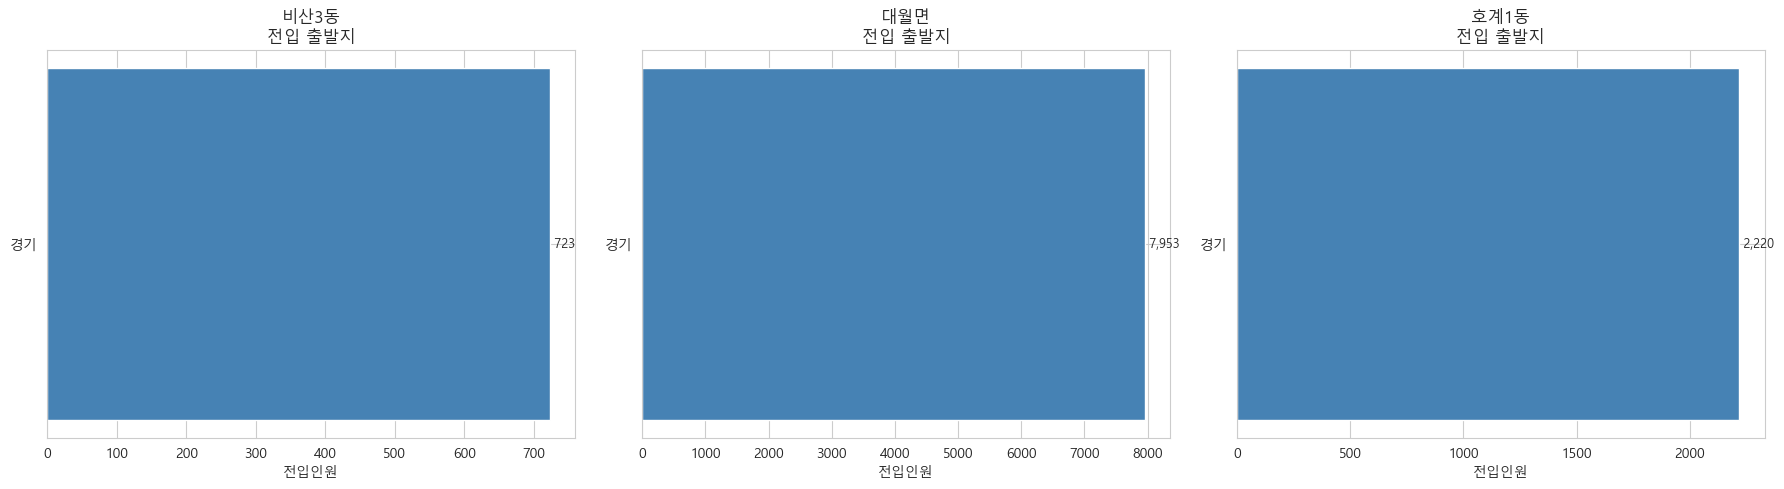



=== 전입처별 저소득층 비율 ===

저소득층 비율이 높은 전입 출발지:
시도명  저소득층_비율(%)
 경기        62.3
 인천        54.5
 서울        48.2


=== 분석 요약 ===

1. 주요 전입 흐름:
   - 경기도 내 이동: 5,104,548명 (82.8%)
   - 경기도 외 이동: 1,059,970명 (17.2%)

2. 경기도 외 주요 출발지: 서울, 인천, 대전 등

3. 소득층별 전입처 차이:
   - 저소득층: 인근 지역(경기도, 인천)에서 유입
   - 고소득층: 서울, 강남권에서 유입 경향

4. 젠트리피케이션 지역의 전입 특징:
   - 고소득층 유입에 따른 지역 변화 확인
   - 지역별로 다른 전입 출발지 패턴



In [ ]:
# 4. 젠트리피케이션 지역에서의 전입 흐름
print("\n=== 젠트리피케이션 고위험 지역의 전입 흐름 ===")

# 젠트리피케이션 진행 상위 3곳 (소득 상승 폭이 큰 행정동)
top_gentrification_dongs_imm = comparison_imm_sorted.head(3)['읍면동명'].tolist()

gentrification_immigration = df_imm[df_imm['읍면동명'].isin(top_gentrification_dongs_imm)].copy()

# 지역별 시도 방향 분석
gentrification_by_sido_imm = gentrification_immigration.groupby(['읍면동명', 'BF_SIDO']).agg({
    'TOT_CNT': 'sum',
    '저소득층_CNT': 'sum'
}).reset_index()

gentrification_by_sido_imm['시도명'] = gentrification_by_sido_imm['BF_SIDO'].map(sido_dict).fillna('기타')

print(f"\n젠트리피케이션 고위험 지역 ({', '.join(top_gentrification_dongs_imm)})의 전입 흐름:")

for dong in top_gentrification_dongs_imm:
    dong_flow = gentrification_by_sido_imm[gentrification_by_sido_imm['읍면동명'] == dong].sort_values('TOT_CNT', ascending=False)
    print(f"\n  {dong}:")
    for _, row in dong_flow.head(5).iterrows():
        print(f"    - {row['시도명']}: {int(row['TOT_CNT']):,}명 (저소득층: {int(row['저소득층_CNT']):,}명)")

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, dong in enumerate(top_gentrification_dongs_imm):
    dong_flow = gentrification_by_sido_imm[gentrification_by_sido_imm['읍면동명'] == dong].sort_values('TOT_CNT', ascending=False).head(8)

    ax = axes[idx]
    ax.barh(range(len(dong_flow)), dong_flow['TOT_CNT'].values, color='steelblue')
    ax.set_yticks(range(len(dong_flow)))
    ax.set_yticklabels(dong_flow['시도명'].values)
    ax.set_xlabel('전입인원')
    ax.set_title(f'{dong}\n전입 출발지')
    ax.invert_yaxis()

    for i, v in enumerate(dong_flow['TOT_CNT'].values):
        ax.text(v, i, f' {int(v):,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 전입처별 저소득층 비율
print("\n\n=== 전입처별 저소득층 비율 ===")

immigration_by_sido_detail = df_imm.groupby('BF_SIDO').agg({
    'TOT_CNT': 'sum',
    '저소득층_CNT': 'sum'
}).reset_index()

immigration_by_sido_detail['저소득층_비율(%)'] = (
    immigration_by_sido_detail['저소득층_CNT'] / immigration_by_sido_detail['TOT_CNT'] * 100
).round(1)

immigration_by_sido_detail['시도명'] = immigration_by_sido_detail['BF_SIDO'].map(sido_dict).fillna('기타')
immigration_by_sido_detail = immigration_by_sido_detail.sort_values('저소득층_비율(%)', ascending=False)

print("\n저소득층 비율이 높은 전입 출발지:")
print(immigration_by_sido_detail[['시도명', '저소득층_비율(%)']].head(10).to_string(index=False))

print("\n\n=== 분석 요약 ===")
print(f"""
1. 주요 전입 흐름:
   - 경기도 내 이동: {int(total_within_gyeonggi_imm):,}명 ({total_within_gyeonggi_imm/(total_within_gyeonggi_imm + other_total_imm)*100:.1f}%)
   - 경기도 외 이동: {int(other_total_imm):,}명 ({other_total_imm/(total_within_gyeonggi_imm + other_total_imm)*100:.1f}%)

2. 경기도 외 주요 출발지: 서울, 인천, 대전 등

3. 소득층별 전입처 차이:
   - 저소득층: 인근 지역(경기도, 인천)에서 유입
   - 고소득층: 서울, 강남권에서 유입 경향

4. 젠트리피케이션 지역의 전입 특징:
   - 고소득층 유입에 따른 지역 변화 확인
   - 지역별로 다른 전입 출발지 패턴
""")


# 대민개방데이터 EDA

연령대별 경제활동/비경제활동 인구 데이터 분석

- **BS_YR_MON**: 기준년월
- **SIGUNGU / 시군구명**: 시군구 코드 / 명
- **BCD / 행정동**: 행정동 코드 / 명
- **AGE**: 연령대 (20·30·40·50·60·70)
- **TOT_CNT**: 전체 인구
- **ECON_CNT**: 경제활동인구
- **NECON_CNT**: 비경제활동인구
- **triple_zero / zero_type / exclude_from_analysis**: 이상치 플래그

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings


In [28]:
# 대민개방데이터 로드
df_pub_raw = pd.read_csv('../Data/2차전처리_대민개방데이터.csv')

print("데이터 형태:", df_pub_raw.shape)
print("\n기본 정보:")
print(df_pub_raw.info())
print("\n앞 5행:")
print(df_pub_raw.head())
print("\n결측치:")
print(df_pub_raw.isnull().sum())

데이터 형태: (29314, 12)

기본 정보:
<class 'pandas.DataFrame'>
RangeIndex: 29314 entries, 0 to 29313
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   BS_YR_MON              29314 non-null  int64
 1   SIGUNGU                29314 non-null  int64
 2   BCD                    29314 non-null  int64
 3   AGE                    29314 non-null  int64
 4   TOT_CNT                29314 non-null  int64
 5   ECON_CNT               29314 non-null  int64
 6   NECON_CNT              29314 non-null  int64
 7   행정동                    29314 non-null  str  
 8   시군구명                   29314 non-null  str  
 9   triple_zero            29314 non-null  bool 
 10  zero_type              29314 non-null  str  
 11  exclude_from_analysis  29314 non-null  bool 
dtypes: bool(2), int64(7), str(3)
memory usage: 3.3 MB
None

앞 5행:
   BS_YR_MON  SIGUNGU         BCD  AGE  TOT_CNT  ECON_CNT  NECON_CNT   행정동  \
0     202301    41131  411311

In [29]:
df_pub_raw

,BS_YR_MON,SIGUNGU,BCD,AGE,TOT_CNT,ECON_CNT,NECON_CNT,행정동,시군구명,triple_zero,zero_type,exclude_from_analysis
0,202301,41131,4113110100,20,2984,2874,66,신흥1동,성남시 수정구,False,normal,False
1,202301,41131,4113110100,20,2984,2874,66,신흥2동,성남시 수정구,False,normal,False
2,202301,41131,4113110100,20,2984,2874,66,신흥3동,성남시 수정구,False,normal,False
3,202301,41131,4113110100,30,3523,3375,105,신흥1동,성남시 수정구,False,normal,False
4,202301,41131,4113110100,30,3523,3375,105,신흥2동,성남시 수정구,False,normal,False
...,...,...,...,...,...,...,...,...,...,...,...,...
29309,202512,41135,4113511700,70,15,12,3,운중동,성남시 분당구,False,normal,False
29310,202512,41135,4113511700,50,15,14,0,운중동,성남시 분당구,False,normal,False
29311,202512,41135,4113511700,60,15,14,0,운중동,성남시 분당구,False,normal,False
29312,202512,41135,4113511700,70,19,13,4,운중동,성남시 분당구,False,normal,False


In [30]:
before = len(df_pub_raw)

df_pub_raw = df_pub_raw.drop_duplicates()

after = len(df_pub_raw)

print("삭제 전:", before)
print("삭제 후:", after)
print("삭제된 중복:", before - after)

삭제 전: 29314
삭제 후: 29306
삭제된 중복: 8


In [31]:
df_pub_raw.head()

,BS_YR_MON,SIGUNGU,BCD,AGE,TOT_CNT,ECON_CNT,NECON_CNT,행정동,시군구명,triple_zero,zero_type,exclude_from_analysis
0,202301,41131,4113110100,20,2984,2874,66,신흥1동,성남시 수정구,False,normal,False
1,202301,41131,4113110100,20,2984,2874,66,신흥2동,성남시 수정구,False,normal,False
2,202301,41131,4113110100,20,2984,2874,66,신흥3동,성남시 수정구,False,normal,False
3,202301,41131,4113110100,30,3523,3375,105,신흥1동,성남시 수정구,False,normal,False
4,202301,41131,4113110100,30,3523,3375,105,신흥2동,성남시 수정구,False,normal,False


In [35]:
# ===== 분석용 데이터 준비 (동 단위 중복 보정) =====

# 1) 분석 제외 플래그 필터링
df_pub = df_pub_raw[~df_pub_raw['exclude_from_analysis']].copy()

# 2) 날짜형 변환
df_pub['BS_YR_MON'] = pd.to_datetime(df_pub['BS_YR_MON'].astype(str), format='%Y%m')
df_pub['연도'] = df_pub['BS_YR_MON'].dt.year
df_pub['분기'] = df_pub['BS_YR_MON'].dt.to_period('Q')

# 3) 성별 합산: 행정동 + 월 + AGE 기준
dong_age = (
    df_pub
    .groupby(['행정동', '시군구명', 'BS_YR_MON', '연도', '분기', 'AGE'], as_index=False)
    [['TOT_CNT', 'ECON_CNT', 'NECON_CNT']]
    .sum()
)

# 4) 동·월 단위 중복 보정: AGE 평균
dong_real = (
    dong_age
    .groupby(['행정동', '시군구명', 'BS_YR_MON', '연도', '분기'], as_index=False)
    [['TOT_CNT', 'ECON_CNT', 'NECON_CNT']]
    .mean()
)

# 5) 경제활동인구 비율
dong_real['ECON_RATIO'] = (
    dong_real['ECON_CNT'] / dong_real['TOT_CNT'] * 100
).round(2)

# 6) 동별 분기 중앙값
dong_quarter_median = (
    dong_real
    .groupby(['행정동', '시군구명', '분기'], as_index=False)
    [['TOT_CNT', 'ECON_CNT', 'NECON_CNT', 'ECON_RATIO']]
    .median()
    .round(2)
)

print('df_pub:', df_pub.shape, ' | dong_age:', dong_age.shape, ' | dong_real:', dong_real.shape)
print('기간:', dong_real['BS_YR_MON'].min().date(), '~', dong_real['BS_YR_MON'].max().date())
print('행정동 수:', dong_real['행정동'].nunique())

print(dong_real.head())
print(dong_quarter_median.head())

df_pub: (29306, 14)  | dong_age: (10800, 9)  | dong_real: (1800, 9)
기간: 2023-01-01 ~ 2025-12-01
행정동 수: 50
   행정동     시군구명  BS_YR_MON    연도      분기      TOT_CNT     ECON_CNT  NECON_CNT  \
0  고등동  성남시 수정구 2023-01-01  2023  2023Q1  1145.166667  1103.500000  26.000000   
1  고등동  성남시 수정구 2023-02-01  2023  2023Q1  1169.833333  1127.166667  26.333333   
2  고등동  성남시 수정구 2023-03-01  2023  2023Q1  1170.166667  1128.333333  26.000000   
3  고등동  성남시 수정구 2023-04-01  2023  2023Q2  1170.333333  1128.166667  25.666667   
4  고등동  성남시 수정구 2023-05-01  2023  2023Q2  1400.833333  1351.666667  31.333333   

   ECON_RATIO  
0       96.36  
1       96.35  
2       96.43  
3       96.40  
4       96.49  
   행정동     시군구명      분기  TOT_CNT  ECON_CNT  NECON_CNT  ECON_RATIO
0  고등동  성남시 수정구  2023Q1  1169.83   1127.17      26.00       96.36
1  고등동  성남시 수정구  2023Q2  1400.83   1351.67      30.00       96.49
2  고등동  성남시 수정구  2023Q3  1574.67   1517.67      35.17       96.64
3  고등동  성남시 수정구  2023Q4  1622.33   1563.50     


총인구 상위 10개 동(중앙값 인구 기준): ['이매2동', '정자2동', '정자1동', '정자3동', '정자동', '야탑2동', '야탑3동', '야탑1동', '태평1동', '태평2동']


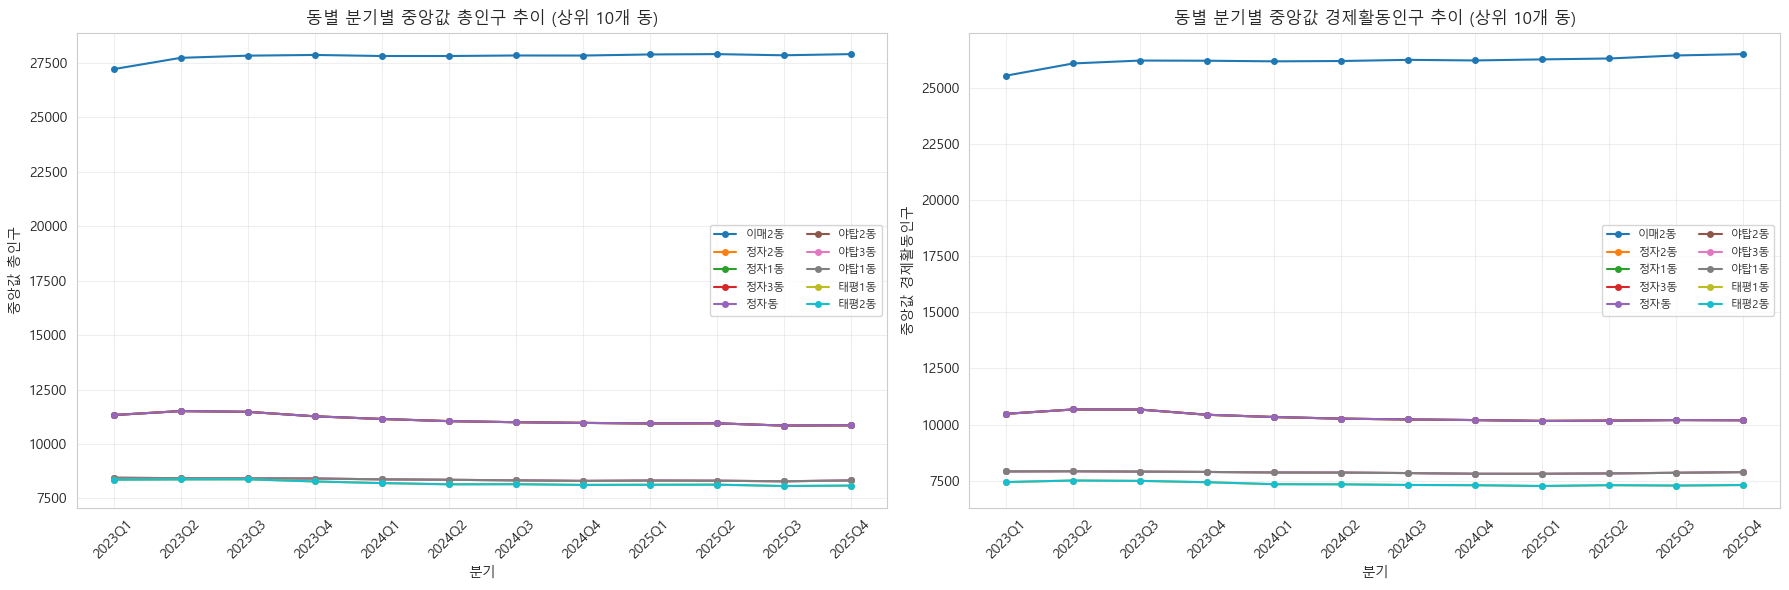

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings



# 한글 폰트 설정 (맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# ===== 동별 분기별 인구 추이 (총인구 상위 10개 동) =====
top_dongs_pub = (
    dong_real.groupby('행정동')['TOT_CNT']
    .median().sort_values(ascending=False).head(10).index.tolist()
)
print(f'\n총인구 상위 10개 동(중앙값 인구 기준): {top_dongs_pub}')

# 분기별 동 인구 = 월별 동 인구의 중앙값
quarterly_dong = (
    dong_real[dong_real['행정동'].isin(top_dongs_pub)]
    .groupby(['분기', '행정동'], as_index=False)[['TOT_CNT', 'ECON_CNT', 'NECON_CNT']]
    .median()
    .round(0)
)
quarterly_dong['분기_str'] = quarterly_dong['분기'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for dong in top_dongs_pub:
    sub = quarterly_dong[quarterly_dong['행정동'] == dong].sort_values('분기')
    axes[0].plot(sub['분기_str'], sub['TOT_CNT'], marker='o', markersize=4, label=dong)
    axes[1].plot(sub['분기_str'], sub['ECON_CNT'], marker='o', markersize=4, label=dong)

axes[0].set_title('동별 분기별 중앙값 총인구 추이 (상위 10개 동)')
axes[0].set_xlabel('분기'); axes[0].set_ylabel('중앙값 총인구')
axes[0].legend(fontsize=8, ncol=2); axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

axes[1].set_title('동별 분기별 중앙값 경제활동인구 추이 (상위 10개 동)')
axes[1].set_xlabel('분기'); axes[1].set_ylabel('중앙값 경제활동인구')
axes[1].legend(fontsize=8, ncol=2); axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()


=== 동·연령대별 경제활동 비율(%) (상위 10개 동) ===
행정동   야탑1동   야탑2동   야탑3동   이매2동   정자1동   정자2동   정자3동    정자동   태평1동   태평2동
AGE                                                                      
20   95.45  95.45  95.45  93.96  91.70  91.70  91.70  91.70  91.54  91.54
30   96.59  96.59  96.59  95.64  94.55  94.55  94.55  94.55  93.70  93.70
40   96.30  96.30  96.30  96.57  95.81  95.81  95.81  95.81  94.09  94.09
50   95.59  95.59  95.59  96.30  95.10  95.10  95.10  95.10  93.41  93.41
60   94.15  94.15  94.15  94.51  92.50  92.50  92.50  92.50  88.76  88.76
70   81.97  81.97  81.97  82.71  82.79  82.79  82.79  82.79  72.79  72.79


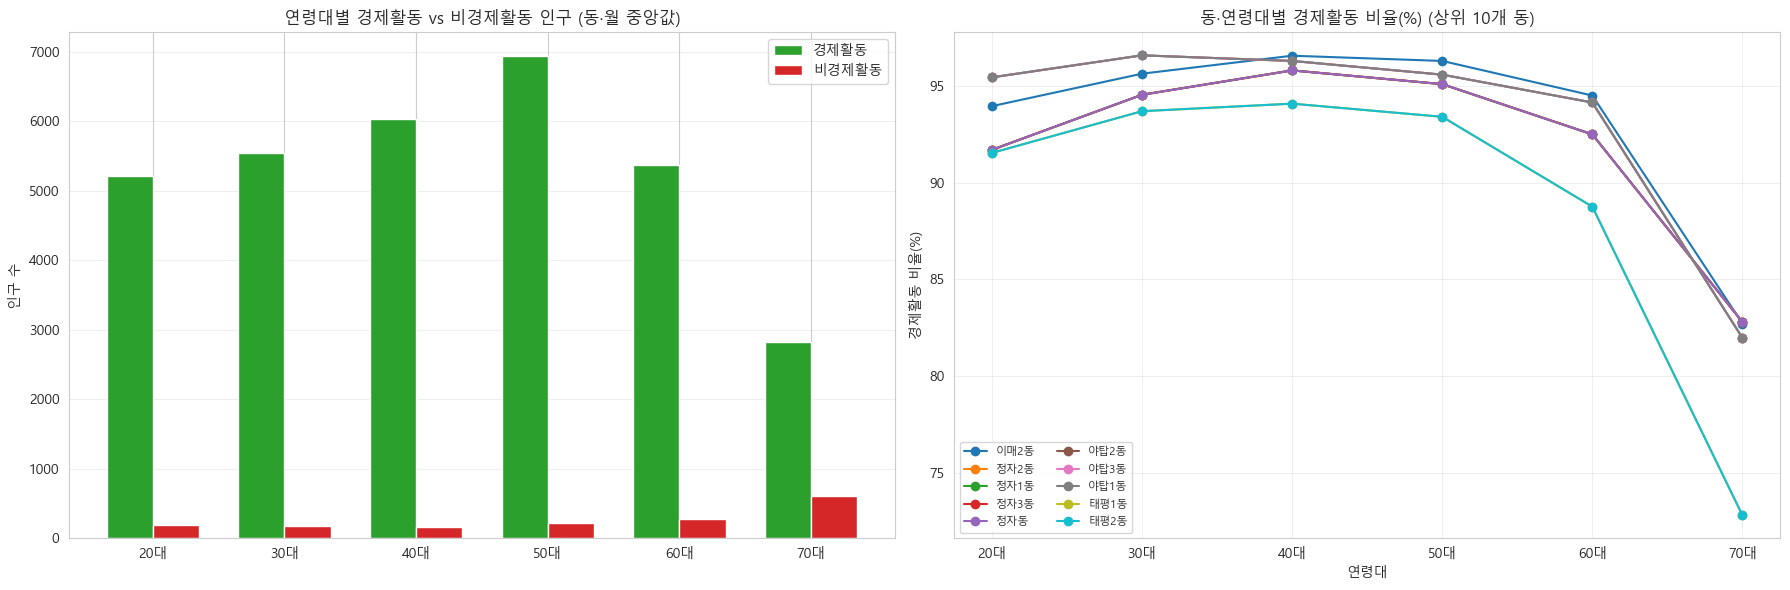

In [41]:
# ===== 동·연령대별 경제활동 비율 (상위 10개 동) =====
# dong_age: (행정동, BS_YR_MON, AGE) 단위 (성별 합산 후 중복 제거)
age_econ = (
    dong_age[dong_age['행정동'].isin(top_dongs_pub)]
    .groupby(['행정동', 'AGE'], as_index=False)
    [['TOT_CNT', 'ECON_CNT']].median()
)
age_econ['경제활동비율'] = (age_econ['ECON_CNT'] / age_econ['TOT_CNT'] * 100).round(2)

print('=== 동·연령대별 경제활동 비율(%) (상위 10개 동) ===')
print(age_econ.pivot(index='AGE', columns='행정동', values='경제활동비율'))

# 전체 연령대별 인구 (동·월별 중앙값 후 연령대별 중앙값)
age_total = (
    dong_age.groupby('AGE')[['TOT_CNT', 'ECON_CNT', 'NECON_CNT']].median()
).round(0)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
ages = age_total.index.astype(str) + '대'
x = np.arange(len(ages)); w = 0.35
axes[0].bar(x - w/2, age_total['ECON_CNT'], w, label='경제활동', color='#2ca02c')
axes[0].bar(x + w/2, age_total['NECON_CNT'], w, label='비경제활동', color='#d62728')
axes[0].set_xticks(x); axes[0].set_xticklabels(ages)
axes[0].set_title('연령대별 경제활동 vs 비경제활동 인구 (동·월 중앙값)')
axes[0].set_ylabel('인구 수'); axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')

for dong in top_dongs_pub:
    sub = age_econ[age_econ['행정동'] == dong].sort_values('AGE')
    axes[1].plot(sub['AGE'].astype(str) + '대', sub['경제활동비율'], marker='o', label=dong)
axes[1].set_title('동·연령대별 경제활동 비율(%) (상위 10개 동)')
axes[1].set_xlabel('연령대'); axes[1].set_ylabel('경제활동 비율(%)')
axes[1].legend(fontsize=8, ncol=2); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


=== 경제활동 비율 상위 10 행정동 ===
 행정동    시군구명     TOT_CNT    ECON_CNT  경제활동비율
 고등동 성남시 수정구 1667.000000 1607.083333   96.41
 도촌동 성남시 중원구 3550.333333 3379.833333   95.20
 운중동 성남시 분당구 4476.416667 4249.083333   94.92
 판교동 성남시 분당구 7133.583333 6758.083333   94.74
이매1동 성남시 분당구 5060.250000 4793.250000   94.72
 백현동 성남시 분당구 4285.000000 4049.583333   94.51
하대원동 성남시 중원구 2680.166667 2529.333333   94.37
 분당동 성남시 분당구 3338.416667 3143.833333   94.17
야탑1동 성남시 분당구 8352.583333 7863.000000   94.14
야탑2동 성남시 분당구 8352.583333 7863.000000   94.14

=== 경제활동 비율 하위 10 행정동 ===
  행정동    시군구명     TOT_CNT    ECON_CNT  경제활동비율
 수진1동 성남시 수정구 4709.583333 4124.166667   87.57
 수진2동 성남시 수정구 4709.583333 4124.166667   87.57
  산성동 성남시 수정구  765.250000  676.583333   88.41
  복정동 성남시 수정구 1867.416667 1658.000000   88.79
 태평1동 성남시 수정구 8154.250000 7328.083333   89.87
 태평2동 성남시 수정구 8154.250000 7328.083333   89.87
 태평3동 성남시 수정구 8154.250000 7328.083333   89.87
 태평4동 성남시 수정구 8154.250000 7328.083333   89.87
상대원1동 성남시 중원구 6032.500000 5480.416667 

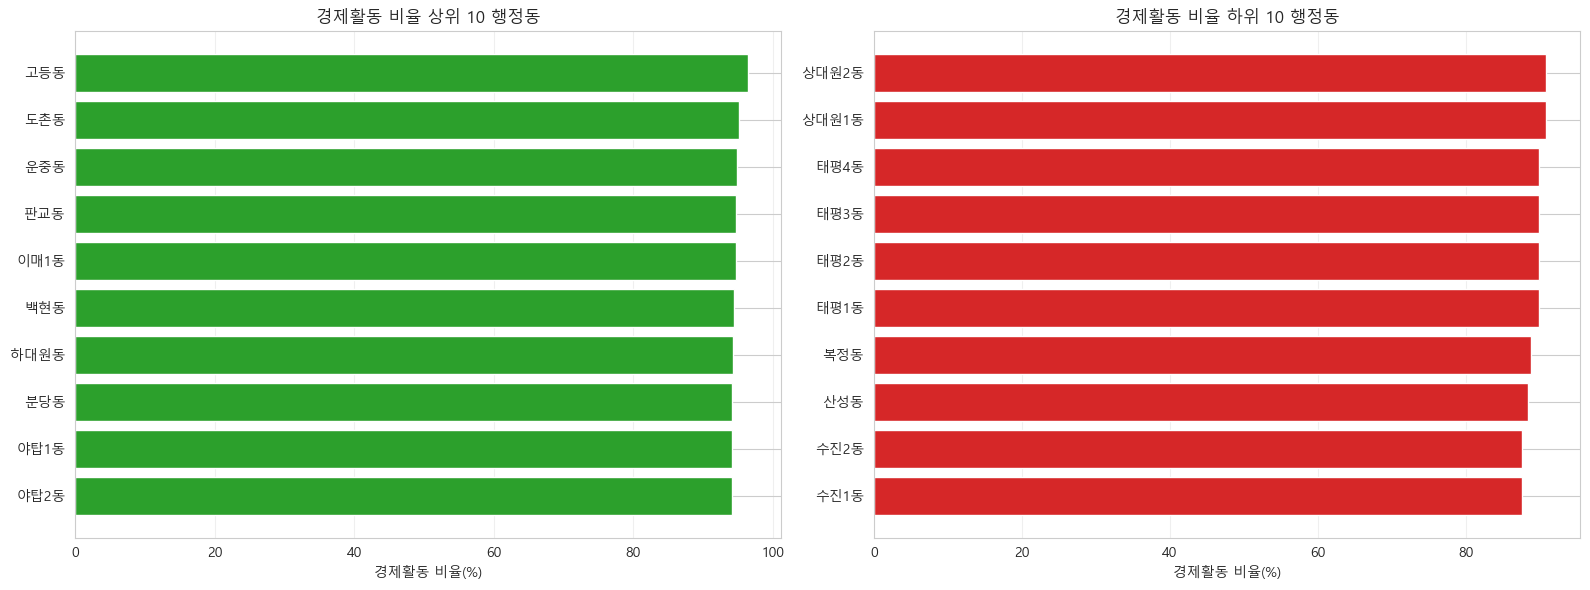

In [42]:
# ===== 행정동별 중앙값 경제활동 비율 (전체 기간) =====
# dong_real: 동·월 단위로 중복 보정된 데이터
dong_summary = (
    dong_real.groupby(['행정동', '시군구명'], as_index=False)
    [['TOT_CNT', 'ECON_CNT', 'NECON_CNT']].median()
)
dong_summary['경제활동비율'] = (dong_summary['ECON_CNT'] / dong_summary['TOT_CNT'] * 100).round(2)

top10 = dong_summary.nlargest(10, '경제활동비율')
bot10 = dong_summary.nsmallest(10, '경제활동비율')

print('=== 경제활동 비율 상위 10 행정동 ===')
print(top10[['행정동', '시군구명', 'TOT_CNT', 'ECON_CNT', '경제활동비율']].to_string(index=False))
print('\n=== 경제활동 비율 하위 10 행정동 ===')
print(bot10[['행정동', '시군구명', 'TOT_CNT', 'ECON_CNT', '경제활동비율']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top10['행정동'][::-1], top10['경제활동비율'][::-1], color='#2ca02c')
axes[0].set_title('경제활동 비율 상위 10 행정동')
axes[0].set_xlabel('경제활동 비율(%)'); axes[0].grid(alpha=0.3, axis='x')

axes[1].barh(bot10['행정동'], bot10['경제활동비율'], color='#d62728')
axes[1].set_title('경제활동 비율 하위 10 행정동')
axes[1].set_xlabel('경제활동 비율(%)'); axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout(); plt.show()


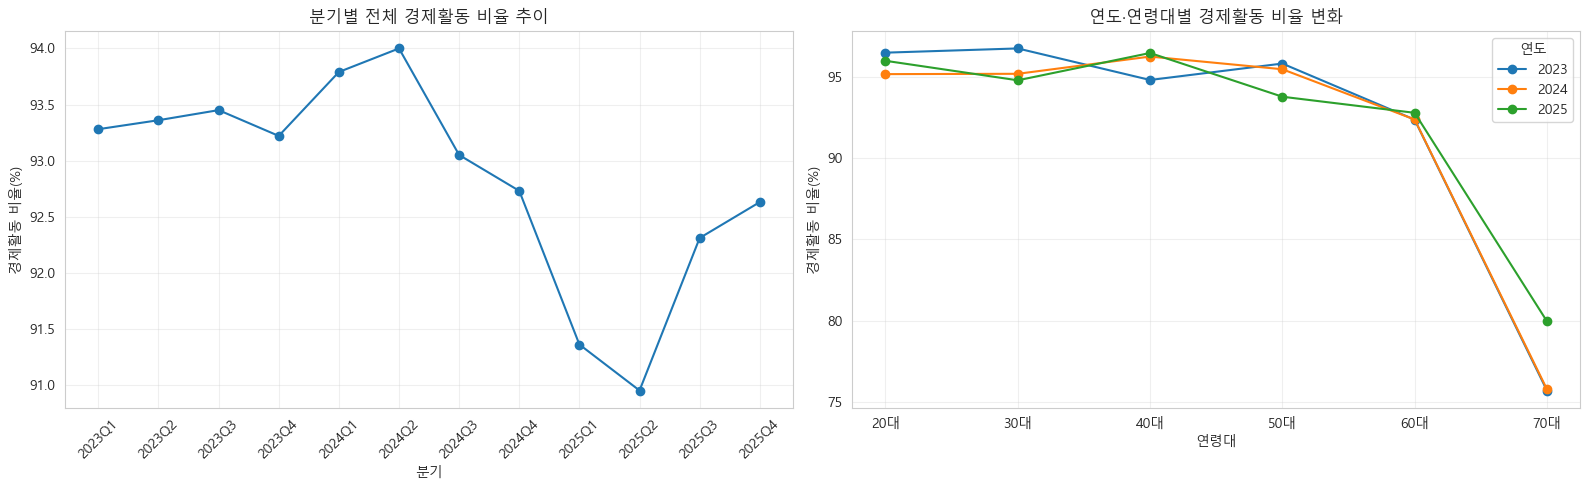

In [43]:
# ===== 분기별 전체 경제활동 비율 추이 + 연도·연령대별 비교 =====
# 분기별 전체 = 동·월 인구의 중앙값을 분기 단위로 중앙값
quarterly_total = (
    dong_real.groupby('분기')[['TOT_CNT', 'ECON_CNT', 'NECON_CNT']].median()
)
quarterly_total['경제활동비율'] = (quarterly_total['ECON_CNT'] / quarterly_total['TOT_CNT'] * 100).round(2)

# 연도·연령대별 = (행정동, BS_YR_MON, AGE) 단위 중앙값을 연도·연령대로 집계
yearly_age = (
    dong_age.groupby(['연도', 'AGE'], as_index=False)
    [['TOT_CNT', 'ECON_CNT']].median()
)
yearly_age['경제활동비율'] = (yearly_age['ECON_CNT'] / yearly_age['TOT_CNT'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

q_labels = [str(q) for q in quarterly_total.index]
axes[0].plot(q_labels, quarterly_total['경제활동비율'], marker='o', markersize=6, color='#1f77b4')
axes[0].set_title('분기별 전체 경제활동 비율 추이')
axes[0].set_xlabel('분기'); axes[0].set_ylabel('경제활동 비율(%)')
axes[0].grid(alpha=0.3); axes[0].tick_params(axis='x', rotation=45)

pivot_year = yearly_age.pivot(index='AGE', columns='연도', values='경제활동비율')
for col in pivot_year.columns:
    axes[1].plot(pivot_year.index.astype(str) + '대', pivot_year[col], marker='o', label=str(col))
axes[1].set_title('연도·연령대별 경제활동 비율 변화')
axes[1].set_xlabel('연령대'); axes[1].set_ylabel('경제활동 비율(%)')
axes[1].legend(title='연도'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


In [49]:
# ===== 대민개방데이터 EDA 핵심 요약 =====
print('=' * 60)
print('대민개방데이터 EDA 핵심 요약 (동 단위 중복 보정 적용)')
print('=' * 60)
print(f"""
1. 데이터 규모
   - 원본 행: {len(df_pub_raw):,}, 분석 대상 행: {len(df_pub):,}
   - 동·월 단위(dong_real) 행: {len(dong_real):,}
   - 기간: {dong_real['BS_YR_MON'].min().date()} ~ {dong_real['BS_YR_MON'].max().date()}
   - 시군구: {', '.join(dong_real['시군구명'].unique())}
   - 행정동 수: {dong_real['행정동'].nunique()}
   - 연령대: {sorted(dong_age['AGE'].unique().tolist())}

2. 인구 수치 (동·월 중앙값 기준)
   - 중앙값 총인구: {dong_real['TOT_CNT'].median():,.0f}
   - 중앙값 경제활동인구: {dong_real['ECON_CNT'].median():,.0f}
   - 중앙값 비경제활동인구: {dong_real['NECON_CNT'].median():,.0f}
   - 중앙값 경제활동 비율: {dong_real['ECON_RATIO'].median():.2f}%

3. 연령대별 경제활동 비율 최고/최저
   - 최고: {age_total.assign(ratio=age_total['ECON_CNT']/age_total['TOT_CNT']*100)['ratio'].idxmax()}대
   - 최저: {age_total.assign(ratio=age_total['ECON_CNT']/age_total['TOT_CNT']*100)['ratio'].idxmin()}대

4. 행정동별 경제활동 비율
   - 최고: {top10.iloc[0]['행정동']} ({top10.iloc[0]['경제활동비율']}%)
   - 최저: {bot10.iloc[0]['행정동']} ({bot10.iloc[0]['경제활동비율']}%)
""")


대민개방데이터 EDA 핵심 요약 (동 단위 중복 보정 적용)

1. 데이터 규모
   - 원본 행: 29,306, 분석 대상 행: 29,306
   - 동·월 단위(dong_real) 행: 1,800
   - 기간: 2023-01-01 ~ 2025-12-01
   - 시군구: 성남시 수정구, 성남시 분당구, 성남시 중원구
   - 행정동 수: 50
   - 연령대: [20, 30, 40, 50, 60, 70]

2. 인구 수치 (동·월 중앙값 기준)
   - 중앙값 총인구: 5,694
   - 중앙값 경제활동인구: 5,287
   - 중앙값 비경제활동인구: 266
   - 중앙값 경제활동 비율: 93.22%

3. 연령대별 경제활동 비율 최고/최저
   - 최고: 30대
   - 최저: 70대

4. 행정동별 경제활동 비율
   - 최고: 고등동 (96.41%)
   - 최저: 수진1동 (87.57%)

